# Proyecto: Minería de Datos - Sistemas de Recomendación con MovieLens 20M
## Minería de Patrones y Similitud con Spark, MinHashing y LSH

---

## SETUP INICIAL: Configuración de Spark y Importaciones

### Paso 1: Configurar la sesión de Spark


In [1]:
# Importaciones de Spark
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
from pyspark.ml.feature import MinHashLSH
from pyspark.ml.linalg import Vectors

# Importaciones cientificas y visualizacion
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import time

# Importaciones GPU (RAPIDS)
try:
    import cudf
    import cuml
    GPU_AVAILABLE = True
    print("✓ cuDF y cuML detectados - GPU acceleration habilitado")
except ImportError:
    GPU_AVAILABLE = False
    print("⚠ cuDF/cuML no disponibles - usando CPU solamente")

# Configuracion visual
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

# =====================================================
# PERFIL DE EJECUCION: quick | full
# Cambia RUN_PROFILE a "quick" si quieres iterar mas rapido
# =====================================================
RUN_PROFILE = "full"

# =====================================================
# ESTRATEGIA: CPU (Spark) + GPU (cuDF/cuML) - HIBRIDA
# Spark maneja I/O y preprocesamiento CPU
# cuDF/cuML aceleran operaciones de ML en GPU cuando estan disponibles
# =====================================================
EXEC_MODE = "HYBRID"  # Spark CPU + GPU para ML
GPU_ENABLED = GPU_AVAILABLE

# =====================================================
# CONFIGURACION DEL DATASET: 30% DE MUESTREO
# =====================================================
DATASET_SAMPLING_PERCENT = 0.30  # Usar 30% del dataset total

PROFILE_SETTINGS = {
    "quick": {
        "spark": {
            "driver_memory": "4g",
            "executor_memory": "4g",
            "shuffle_partitions": "120",
            "default_parallelism": "120"
        },
        "sample_size": 0.10,
        "num_hash_functions": 400,
        "lsh_configurations": [(50, 8), (80, 5), (100, 4), (200, 2)],
        "lsh_real_threshold": 0.85,
        "spark_lsh_num_hash_tables": 48,
        "spark_distance_threshold": 0.35
    },
    "full": {
        "spark": {
            "driver_memory": "8g",
            "executor_memory": "8g",
            "shuffle_partitions": "400",
            "default_parallelism": "400"
        },
        "sample_size": 0.10,
        "num_hash_functions": 1200,
        "lsh_configurations": [(120, 10), (150, 8), (240, 5), (300, 4), (600, 2)],
        "lsh_real_threshold": 0.85,
        "spark_lsh_num_hash_tables": 96,
        "spark_distance_threshold": 0.30
    }
}

if RUN_PROFILE not in PROFILE_SETTINGS:
    raise ValueError("RUN_PROFILE debe ser 'quick' o 'full'")

settings = PROFILE_SETTINGS[RUN_PROFILE]
spark_cfg = settings["spark"]
SAMPLE_SIZE_SETTING = settings["sample_size"]

# Si ya existe una sesion, la cerramos para aplicar nueva configuracion
if "spark" in globals():
    try:
        spark.stop()
    except Exception:
        pass

# Inicializar sesion de Spark (SOLO CPU, sin plugin RAPIDS)
spark = SparkSession.builder \
    .appName(f"MovieLens-20M-MinHash-LSH-{RUN_PROFILE}-HYBRID") \
    .config("spark.driver.memory", spark_cfg["driver_memory"]) \
    .config("spark.executor.memory", spark_cfg["executor_memory"]) \
    .config("spark.sql.shuffle.partitions", spark_cfg["shuffle_partitions"]) \
    .config("spark.default.parallelism", spark_cfg["default_parallelism"]) \
    .config("spark.sql.adaptive.enabled", "true") \
    .getOrCreate()

# Configurar nivel de log
spark.sparkContext.setLogLevel("WARN")

# Parametros globales reutilizados en las secciones pesadas
SAMPLE_SIZE = settings["sample_size"]
NUM_HASH_FUNCTIONS = settings["num_hash_functions"]
LSH_CONFIGURATIONS = settings["lsh_configurations"]
LSH_REAL_THRESHOLD = settings["lsh_real_threshold"]
SPARK_LSH_NUM_HASH_TABLES = settings["spark_lsh_num_hash_tables"]
SPARK_APPROX_DISTANCE_THRESHOLD = settings["spark_distance_threshold"]

print("✓ Spark sesion inicializada correctamente")
print(f"✓ Spark version: {spark.version}")
print(f"✓ Perfil activo: {RUN_PROFILE}")
print(f"✓ Modo de ejecucion: {EXEC_MODE}")
print(f"✓ GPU acceleration (cuDF/cuML): {'HABILITADO' if GPU_ENABLED else 'DESHABILITADO'}")
print(f"✓ Spark driver/executor: {spark_cfg['driver_memory']} / {spark_cfg['executor_memory']}")
print(f"✓ Dataset sampling: {DATASET_SAMPLING_PERCENT*100:.0f}%")
if isinstance(SAMPLE_SIZE_SETTING, float) and SAMPLE_SIZE_SETTING <= 1:
    print(f"✓ sample_size configurado: {SAMPLE_SIZE_SETTING*100:.0f}% del total")
else:
    print(f"✓ sample_size configurado: {SAMPLE_SIZE_SETTING}")
print(f"✓ num_hash_functions={NUM_HASH_FUNCTIONS}")
print(f"✓ spark_lsh_num_hash_tables={SPARK_LSH_NUM_HASH_TABLES}, dist_threshold={SPARK_APPROX_DISTANCE_THRESHOLD}")

if GPU_ENABLED:
    print("\n📊 GPU Setup:")
    print(f"   cuDF version: {cudf.__version__}")
    print(f"   cuML version: {cuml.__version__}")
    print("   GPU acceleration lista para operaciones de ML")


✓ cuDF y cuML detectados - GPU acceleration habilitado


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/30 17:19:56 WARN Utils: Your hostname, DESKTOP-FI2LTPS, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/04/30 17:19:56 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/30 17:19:56 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


✓ Spark sesion inicializada correctamente
✓ Spark version: 4.1.1
✓ Perfil activo: full
✓ Modo de ejecucion: HYBRID
✓ GPU acceleration (cuDF/cuML): HABILITADO
✓ Spark driver/executor: 8g / 8g
✓ Dataset sampling: 30%
✓ sample_size configurado: 10% del total
✓ num_hash_functions=1200
✓ spark_lsh_num_hash_tables=96, dist_threshold=0.3

📊 GPU Setup:
   cuDF version: 26.02.01
   cuML version: 26.02.00
   GPU acceleration lista para operaciones de ML


### Paso 2: Cargar los datos del dataset MovieLens 20M

Cargaremos los archivos CSV principales en DataFrames de Spark para procesarlos de manera distribuida:
- **ratings.csv:** Contiene todas las calificaciones
- **movies.csv:** Información sobre películas y géneros
- **tags.csv:** Tags asignados por usuarios

In [2]:
# Definir ruta base del dataset
dataset_path = "ml-20m/ml-20m"

# Definir esquema explicito para evitar inferencias incorrectas
from pyspark.sql.types import StructType, StructField, IntegerType, StringType, FloatType, LongType

ratings_schema = StructType([
    StructField("userId", IntegerType(), False),
    StructField("movieId", IntegerType(), False),
    StructField("rating", FloatType(), False),
    StructField("timestamp", LongType(), False)
])

movies_schema = StructType([
    StructField("movieId", IntegerType(), False),
    StructField("title", StringType(), False),
    StructField("genres", StringType(), False)
])

tags_schema = StructType([
    StructField("userId", IntegerType(), False),
    StructField("movieId", IntegerType(), False),
    StructField("tag", StringType(), False),
    StructField("timestamp", LongType(), False)
])

# Cargar ratings.csv
print("Cargando ratings.csv...")
ratings = spark.read.csv(
    f"{dataset_path}/ratings.csv",
    header=True,
    schema=ratings_schema
)
print(f"✓ Ratings cargadas: {ratings.count()} registros")
ratings.printSchema()

print("\n" + "=" * 80 + "\n")

# Cargar movies.csv
print("Cargando movies.csv...")
movies = spark.read.csv(
    f"{dataset_path}/movies.csv",
    header=True,
    schema=movies_schema
)
print(f"✓ Movies cargadas: {movies.count()} peliculas")
movies.printSchema()

print("\n" + "=" * 80 + "\n")

# Cargar tags.csv
print("Cargando tags.csv...")
tags = spark.read.csv(
    f"{dataset_path}/tags.csv",
    header=True,
    schema=tags_schema
)
print(f"✓ Tags cargados: {tags.count()} registros")
tags.printSchema()

print("\n✓ Todos los archivos cargados correctamente")

Cargando ratings.csv...


✓ Ratings cargadas: 20000263 registros
root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- rating: float (nullable = true)
 |-- timestamp: long (nullable = true)



Cargando movies.csv...
✓ Movies cargadas: 27278 peliculas
root
 |-- movieId: integer (nullable = true)
 |-- title: string (nullable = true)
 |-- genres: string (nullable = true)



Cargando tags.csv...
✓ Tags cargados: 465564 registros
root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- tag: string (nullable = true)
 |-- timestamp: long (nullable = true)


✓ Todos los archivos cargados correctamente


---

# PARTE I: PREPROCESAMIENTO Y EXPLORACIÓN DE DATOS (EDA)

## Introducción a la Parte I

En esta sección realizaremos:
1. **Limpieza y preprocesamiento:** Eliminar nulos, inconsistencias y duplicados
2. **Normalización:** Unificar etiquetas de géneros
3. **Transformación:** Convertir ratings a escala binaria (like/dislike)
4. **Exploración:** Análisis estadístico y visualización del dataset

Estas operaciones se ejecutarán con **Spark SQL y DataFrames** para aprovechar el procesamiento distribuido en el dataset completo.

---

## 1.1 PREPROCESAMIENTO

### Paso 1: Detectar y manejar valores nulos

In [3]:
# Detectar valores nulos en cada dataset
print("ANÁLISIS DE VALORES NULOS\n")

# Usar solo isNull() para evitar problemas con tipo casting en isnan()
print("Ratings:")
ratings.select([count(when(col(c).isNull(), c)).alias(c) for c in ratings.columns]).show()

print("\nMovies:")
movies.select([count(when(col(c).isNull(), c)).alias(c) for c in movies.columns]).show()

print("\nTags:")
tags.select([count(when(col(c).isNull(), c)).alias(c) for c in tags.columns]).show()

# Eliminar registros con valores nulos
ratings_clean = ratings.dropna()
movies_clean = movies.dropna()
tags_clean = tags.dropna()

print("\n" + "="*80)
print("Después de eliminar nulos:")
print(f"Ratings: {ratings.count()} → {ratings_clean.count()}")
print(f"Movies: {movies.count()} → {movies_clean.count()}")
print(f"Tags: {tags.count()} → {tags_clean.count()}")

ANÁLISIS DE VALORES NULOS

Ratings:


+------+-------+------+---------+
|userId|movieId|rating|timestamp|
+------+-------+------+---------+
|     0|      0|     0|        0|
+------+-------+------+---------+


Movies:
+-------+-----+------+
|movieId|title|genres|
+-------+-----+------+
|      0|    0|     0|
+-------+-----+------+


Tags:
+------+-------+---+---------+
|userId|movieId|tag|timestamp|
+------+-------+---+---------+
|     0|      0|  0|        0|
+------+-------+---+---------+


Después de eliminar nulos:


Ratings: 20000263 → 20000263
Movies: 27278 → 27278
Tags: 465564 → 465564


### Paso 2: Eliminar duplicados

In [4]:
# Detectar duplicados en ratings
# Un duplicado sería el mismo usuario calificando la misma película más de una vez
print("ANÁLISIS DE DUPLICADOS\n")

print(f"Ratings antes de remover duplicados: {ratings_clean.count()}")
ratings_dedupe = ratings_clean.dropDuplicates(["userId", "movieId"])
print(f"Ratings después de remover duplicados: {ratings_dedupe.count()}")

print(f"\nMovies antes de remover duplicados: {movies_clean.count()}")
movies_dedupe = movies_clean.dropDuplicates(["movieId"])
print(f"Movies después de remover duplicados: {movies_dedupe.count()}")

print(f"\nTags antes de remover duplicados: {tags_clean.count()}")
tags_dedupe = tags_clean.dropDuplicates(["userId", "movieId", "tag"])
print(f"Tags después de remover duplicados: {tags_dedupe.count()}")

ANÁLISIS DE DUPLICADOS



Ratings antes de remover duplicados: 20000263


Ratings después de remover duplicados: 20000263

Movies antes de remover duplicados: 27278
Movies después de remover duplicados: 27278

Tags antes de remover duplicados: 465564
Tags después de remover duplicados: 465564


### Paso 3: Transformar ratings a escala binaria

**Justificación de la escala binaria:**
- Las similitudes de Jaccard y MinHashing funcionan mejor con conjuntos binarios
- Un threshold de 3.5 estrella es un punto de corte razonable: separa "películas bien calificadas" de las mediocres
- Facilita la interpretación: una película es "liked" (≥3.5) o "disliked" (<3.5)

In [5]:
# Definir umbral para escala binaria
RATING_THRESHOLD = 3.5

# Transformar ratings a escala binaria (1 = like, 0 = dislike)
ratings_binary = ratings_dedupe.withColumn(
    "binary_rating",
    when(col("rating") >= RATING_THRESHOLD, 1).otherwise(0)
).select("userId", "movieId", "rating", "binary_rating", "timestamp")

print(f"DISTRIBUCIÓN DE RATINGS BINARIOS (threshold = {RATING_THRESHOLD}):\n")
ratings_binary.groupBy("binary_rating").count().show()

# Estadísticas de la conversión
total_ratings = ratings_binary.count()
likes = ratings_binary.filter(col("binary_rating") == 1).count()
dislikes = total_ratings - likes

print(f"\nTotal de ratings: {total_ratings}")
print(f"Likes (rating >= {RATING_THRESHOLD}): {likes} ({100*likes/total_ratings:.2f}%)")
print(f"Dislikes (rating < {RATING_THRESHOLD}): {dislikes} ({100*dislikes/total_ratings:.2f}%)")

# Mostrar ejemplo de transformación
print("\nEJEMPLO DE TRANSFORMACIÓN:")
ratings_binary.limit(5).show()

DISTRIBUCIÓN DE RATINGS BINARIOS (threshold = 3.5):



+-------------+--------+
|binary_rating|   count|
+-------------+--------+
|            0| 7804697|
|            1|12195566|
+-------------+--------+




Total de ratings: 20000263
Likes (rating >= 3.5): 12195566 (60.98%)
Dislikes (rating < 3.5): 7804697 (39.02%)

EJEMPLO DE TRANSFORMACIÓN:


+------+-------+------+-------------+----------+
|userId|movieId|rating|binary_rating| timestamp|
+------+-------+------+-------------+----------+
|     1|   1208|   3.5|            1|1112484815|
|     1|   1348|   3.5|            1|1094786056|
|     5|   1080|   5.0|            1| 851617674|
|     7|   1101|   3.0|            0|1011208112|
|     7|   2363|   3.0|            0|1011206779|
+------+-------+------+-------------+----------+



### Paso 4: Normalizar géneros

**Justificación:**
- MovieLens contiene variaciones inconsistentes en géneros (e.g., "Sci-Fi" vs "Science Fiction", mayúsculas inconsistentes)
- La normalización asegura que análisis posteriores agrupen correctamente películas del mismo género
- Eliminamos géneros especiales (IMAX, no-genres) que no representan géneros reales


In [6]:
#!pip install nltk

In [7]:
# =====================================================
# NORMALIZACIÓN DE GÉNEROS MEJORADA CON SNOWBALL STEMMER
# =====================================================

print("NORMALIZACIÓN DE GÉNEROS (Snowball Stemmer + Frecuencia)\n")
print("=" * 80)

# Importaciones necesarias
import string
import nltk
from nltk.stem.snowball import SnowballStemmer
from pyspark.sql.functions import *
from pyspark.sql.types import StringType
from pyspark.sql import SparkSession
from collections import Counter

# Descargar recursos NLTK si es necesario
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

# Stemmer mejorado para inglés (mejor que Porter para variantes)
stemmer = SnowballStemmer("english")

def get_genre_stem_key(genre):
    """Extrae stem key robusto: elimina puntuación, stemming por palabra"""
    if not genre or genre.strip() == "(no genres listed)":
        return "unknown"
    
    # Limpiar: minúsculas, remover TODA puntuación (incluye - de sci-fi)
    clean_genre = genre.strip().lower().translate(str.maketrans('', '', string.punctuation))
    clean_genre = clean_genre.replace("_", " ")
    
    # Stem cada palabra
    words = clean_genre.split()
    stems = [stemmer.stem(word) for word in words if word]  # Ignorar palabras vacías
    
    return " ".join(stems)

# Crear mapeo stem → género MÁS FRECUENTE (no más largo)
print("Creando mapeo automático por frecuencia...\n")

# Obtener géneros únicos (asumiendo movies_dedupe existe con columna 'genres')
all_genres_raw = movies_dedupe.select(
    explode(split(col("genres"), "\\|")).alias("genre")
).select("genre").distinct().collect()

# Diccionario para contar ocurrencias por stem
stem_to_genres_count = {}
for row in all_genres_raw:
    genre = row['genre']
    stem_key = get_genre_stem_key(genre)
    
    if stem_key not in stem_to_genres_count:
        stem_to_genres_count[stem_key] = Counter()
    stem_to_genres_count[stem_key][genre] += 1

# Crear mapeo: cada género → su canónico (el más frecuente en su grupo)
genre_mapping = {}
for stem_key, genre_counter in stem_to_genres_count.items():
    canonical_genre = genre_counter.most_common(1)[0][0]  # Más frecuente
    for genre in genre_counter.keys():
        genre_mapping[genre] = canonical_genre

# UDF para aplicar mapeo
genre_mapping_broadcast = spark.sparkContext.broadcast(genre_mapping)

def map_genres_array(genres_str):
    if not genres_str or genres_str.strip() == "":
        return genres_str
    
    genres = genres_str.split("|")
    mapped_genres = [genre_mapping_broadcast.value.get(g.strip(), g.strip()) for g in genres]
    return "|".join(mapped_genres)

map_genres_array_udf = udf(map_genres_array, StringType())

# Aplicar normalización
print("Aplicando normalización...\n")
movies_normalized = movies_dedupe.select(
    "movieId", "title", "genres",
    map_genres_array_udf(col("genres")).alias("genres_normalized")
)

# Ejemplos específicos para Sci-Fi
print("EJEMPLO SCI-FI (antes/después):\n")
sci_fi_examples = movies_normalized.filter(
    col("genres").contains("Sci") | col("genres").contains("sci")
).select("title", "genres", "genres_normalized").limit(10)

sci_fi_examples.show(truncate=False)

# Estadísticas completas
print("\n" + "=" * 80)
print("ESTADÍSTICAS\n")

genres_before = movies_dedupe.select(
    explode(split(col("genres"), "\\|")).alias("genre")
).groupBy("genre").count().orderBy(desc("count"))

genres_after = movies_normalized.select(
    explode(split(col("genres_normalized"), "\\|")).alias("genre")
).groupBy("genre").count().orderBy(desc("count"))

print(f"Géneros únicos ANTES: {genres_before.count()}")
print(f"Géneros únicos DESPUÉS: {genres_after.count()}")

print("\nTop 10 ANTES:")
genres_before.show()

print("\nTop 10 DESPUÉS:")
genres_after.show()

reduction = (1 - genres_after.count() / genres_before.count()) * 100
print(f"\n✓ Reducción: {reduction:.1f}% ({genres_before.count()} → {genres_after.count()})")

# Actualizar dataset (reemplaza genres original)
movies_dedupe = movies_normalized.drop("genres").withColumnRenamed("genres_normalized", "genres")
print("\n✓ movies_dedupe actualizado con géneros normalizados!")

print("\n" + "=" * 100)
print("FAMILIAS DE GÉNEROS AGRUPADOS (por stem_key)")
print("=" * 100)
print(f"{'Familia (stem)':<25} | {'Géneros originales → Canónico':<70}")
print("-" * 100)

# Recrear agrupaciones para mostrar
stem_groups = {}
for genre, canonical in genre_mapping.items():
    stem_key = get_genre_stem_key(genre)
    if stem_key not in stem_groups:
        stem_groups[stem_key] = []
    if genre != canonical:  # Solo variantes (no el canónico)
        stem_groups[stem_key].append(genre)

# Mostrar familias con múltiples variantes (ordenadas por tamaño)
multi_groups = {k: v for k, v in stem_groups.items() if len(v) > 0}
for stem_key in sorted(multi_groups, key=lambda k: len(multi_groups[k]), reverse=True):
    variants = multi_groups[stem_key]
    canonical = genre_mapping[variants[0]]  # Canónico del grupo
    print(f"{stem_key:<25} | {str(variants)[:65]} → {canonical}")
    print("-" * 100)

print(f"\n✓ Total familias con duplicados: {len(multi_groups)}")

NORMALIZACIÓN DE GÉNEROS (Snowball Stemmer + Frecuencia)

Creando mapeo automático por frecuencia...

Aplicando normalización...

EJEMPLO SCI-FI (antes/después):



+---------------------------------------------------------------+--------------------------------------+--------------------------------------+
|title                                                          |genres                                |genres_normalized                     |
+---------------------------------------------------------------+--------------------------------------+--------------------------------------+
|Powder (1995)                                                  |Drama|Sci-Fi                          |Drama|Sci-Fi                          |
|City of Lost Children, The (Cité des enfants perdus, La) (1995)|Adventure|Drama|Fantasy|Mystery|Sci-Fi|Adventure|Drama|Fantasy|Mystery|Sci-Fi|
|Twelve Monkeys (a.k.a. 12 Monkeys) (1995)                      |Mystery|Sci-Fi|Thriller               |Mystery|Sci-Fi|Thriller               |
|Lawnmower Man 2: Beyond Cyberspace (1996)                      |Action|Sci-Fi|Thriller                |Action|Sci-Fi|Thriller          

---

## 1.2 EXPLORACIÓN DE DATOS (EDA)

### Paso 1: Distribución de calificaciones originales

DISTRIBUCIÓN DE RATINGS ORIGINALES



Distribución:


  Rating 0.5: 239,125 (1.20%)


  Rating 1.0: 680,732 (3.40%)


  Rating 1.5: 279,252 (1.40%)


...

  Rating 3.5: 2,200,156 (11.00%)


  Rating 4.0: 5,561,926 (27.81%)


  Rating 4.5: 1,534,824 (7.67%)


  Rating 5.0: 2,898,660 (14.49%)



ESTADÍSTICAS DESCRIPTIVAS:
  Total: 20000263.00
  Media: 3.53
  Desv. Est.: 1.05
  Mínimo: 0.50
  Máximo: 5.00
  Q1: 3.00
  Mediana: 3.50
  Q3: 4.00


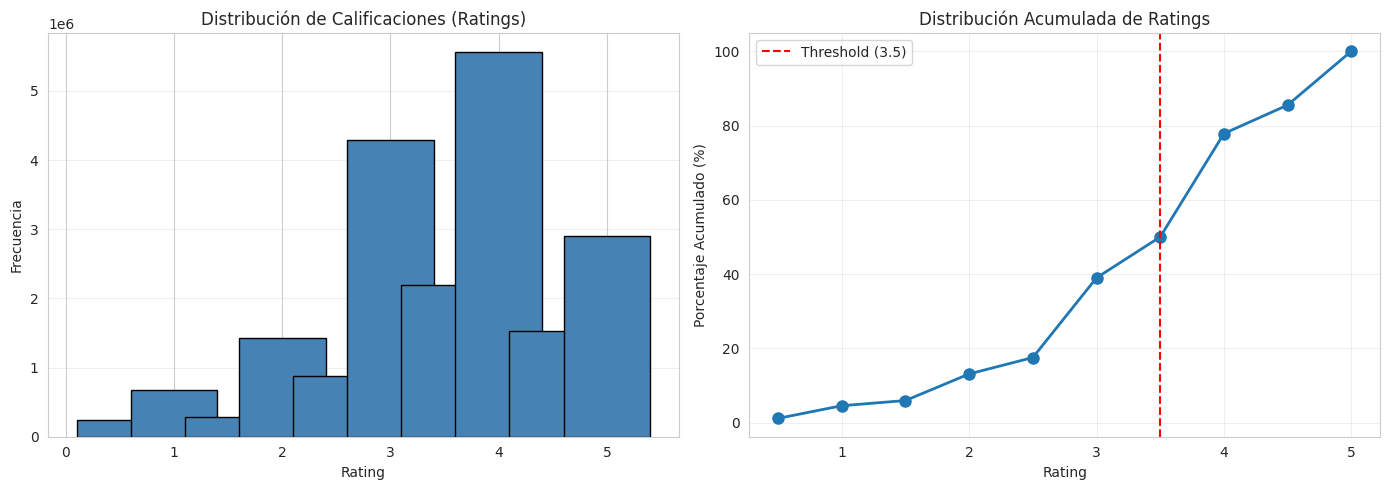

- La mayor concentración de ratings está en valores intermedios-altos, con sesgo hacia calificaciones positivas.
- El umbral 3.5 separa una zona de mayor preferencia, útil para binarizar likes/dislikes.

✓ Gráficas generadas


In [8]:
# Análisis de distribución de ratings
print("DISTRIBUCIÓN DE RATINGS ORIGINALES\n")

rating_distribution = ratings_dedupe.groupBy("rating").count().orderBy("rating").collect()
print("Distribución:")
for row in rating_distribution:
    print(f"  Rating {row['rating']}: {row['count']:,} ({100*row['count']/ratings_dedupe.count():.2f}%)")

# Estadísticas descriptivas
rating_stats = ratings_dedupe.select(
    count("*").alias("Total"),
    avg("rating").alias("Media"),
    stddev("rating").alias("Desv. Est."),
    min("rating").alias("Mínimo"),
    max("rating").alias("Máximo"),
    percentile_approx("rating", 0.25).alias("Q1"),
    percentile_approx("rating", 0.5).alias("Mediana"),
    percentile_approx("rating", 0.75).alias("Q3")
).collect()

print("\nESTADÍSTICAS DESCRIPTIVAS:")
for col_name in ["Total", "Media", "Desv. Est.", "Mínimo", "Máximo", "Q1", "Mediana", "Q3"]:
    val = rating_stats[0][col_name]
    print(f"  {col_name}: {val:.2f}")

# Convertir a pandas para graficar (usar DataFrame API en lugar de SQL)
rating_dist_pd = ratings_dedupe.groupBy("rating").count().orderBy("rating").toPandas()

# Crear gráfica de distribución
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].bar(rating_dist_pd['rating'], rating_dist_pd['count'], color='steelblue', edgecolor='black')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de Calificaciones (Ratings)')
axes[0].grid(axis='y', alpha=0.3)

# Distribución acumulada
rating_dist_pd['cumsum'] = rating_dist_pd['count'].cumsum()
rating_dist_pd['cumsum_pct'] = 100 * rating_dist_pd['cumsum'] / rating_dist_pd['count'].sum()
axes[1].plot(rating_dist_pd['rating'], rating_dist_pd['cumsum_pct'], marker='o', linewidth=2, markersize=8)
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Porcentaje Acumulado (%)')
axes[1].set_title('Distribución Acumulada de Ratings')
axes[1].grid(True, alpha=0.3)
axes[1].axvline(x=RATING_THRESHOLD, color='red', linestyle='--', label=f'Threshold ({RATING_THRESHOLD})')
axes[1].legend()

plt.tight_layout()
plt.show()

print("- La mayor concentración de ratings está en valores intermedios-altos, con sesgo hacia calificaciones positivas.")
print(f"- El umbral {RATING_THRESHOLD} separa una zona de mayor preferencia, útil para binarizar likes/dislikes.")

print("\n✓ Gráficas generadas")

### Paso 2: Análisis de ratings por usuario

ANÁLISIS DE RATINGS POR USUARIO



Número de usuarios: 138,493
Media de ratings por usuario: 144.41
Desviación estándar: 230.27
Mínimo: 20
Máximo: 9254
Mediana: 68

TOP 10 USUARIOS MÁS ACTIVOS:


  Usuario 118205: 9254 ratings
  Usuario 8405: 7515 ratings
  Usuario 82418: 5646 ratings
  Usuario 121535: 5520 ratings
  Usuario 125794: 5491 ratings
  Usuario 74142: 5447 ratings
  Usuario 34576: 5356 ratings
  Usuario 131904: 5330 ratings
  Usuario 83090: 5169 ratings
  Usuario 59477: 4988 ratings


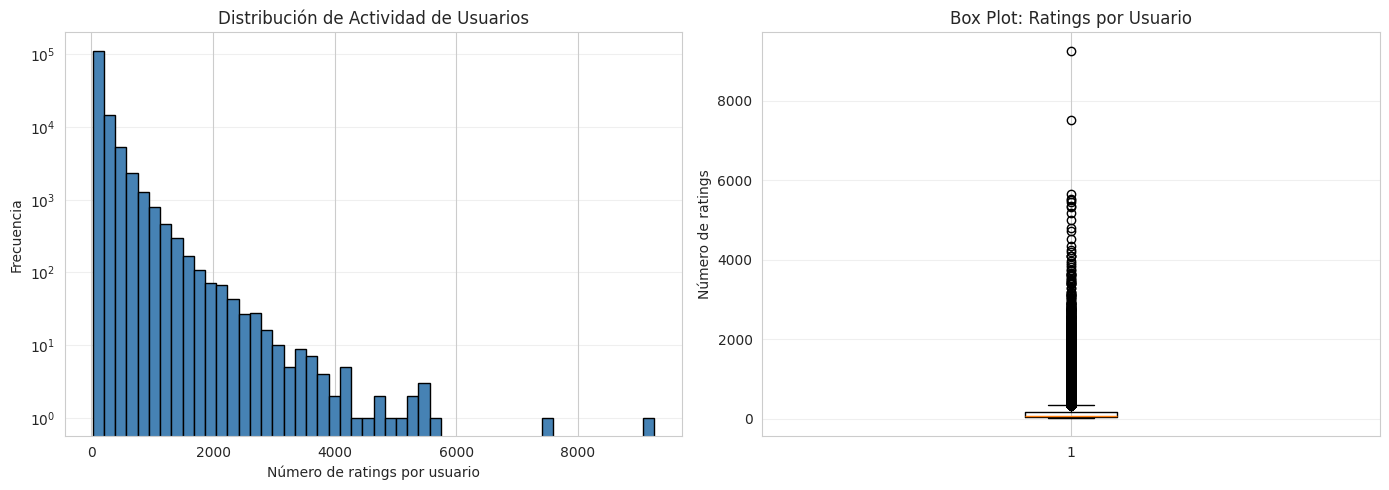

- La actividad de usuarios es altamente desigual: pocos usuarios concentran muchos ratings y la mayoría participa poco.
- La escala logarítmica y el boxplot evidencian una cola larga típica en sistemas de recomendación.


In [9]:
# Análisis de ratings por usuario
print("ANÁLISIS DE RATINGS POR USUARIO\n")

# Contar ratings por usuario
ratings_per_user = ratings_dedupe.groupBy("userId").agg(count("*").alias("num_ratings"))

# Estadísticas
user_stats = ratings_per_user.select(
    count("*").alias("Num_Usuarios"),
    avg("num_ratings").alias("Media_Ratings_Por_Usuario"),
    stddev("num_ratings").alias("Desv_Est"),
    min("num_ratings").alias("Min"),
    max("num_ratings").alias("Max"),
    percentile_approx("num_ratings", 0.5).alias("Mediana")
).collect()[0]

print(f"Número de usuarios: {int(user_stats['Num_Usuarios']):,}")
print(f"Media de ratings por usuario: {user_stats['Media_Ratings_Por_Usuario']:.2f}")
print(f"Desviación estándar: {user_stats['Desv_Est']:.2f}")
print(f"Mínimo: {int(user_stats['Min'])}")
print(f"Máximo: {int(user_stats['Max'])}")
print(f"Mediana: {int(user_stats['Mediana'])}")

# Top 10 usuarios más activos
print("\nTOP 10 USUARIOS MÁS ACTIVOS:")
top_users = ratings_per_user.orderBy(desc("num_ratings")).limit(10)
for row in top_users.collect():
    print(f"  Usuario {row['userId']}: {row['num_ratings']} ratings")

# Gráficas
ratings_per_user_pd = ratings_per_user.toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de ratings por usuario
axes[0].hist(ratings_per_user_pd['num_ratings'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Número de ratings por usuario')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de Actividad de Usuarios')
axes[0].set_yscale('log')
axes[0].grid(axis='y', alpha=0.3)

# Box plot
axes[1].boxplot(ratings_per_user_pd['num_ratings'], vert=True)
axes[1].set_ylabel('Número de ratings')
axes[1].set_title('Box Plot: Ratings por Usuario')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("- La actividad de usuarios es altamente desigual: pocos usuarios concentran muchos ratings y la mayoría participa poco.")
print("- La escala logarítmica y el boxplot evidencian una cola larga típica en sistemas de recomendación.")


### Paso 3: Análisis de ratings por película

ANÁLISIS DE RATINGS POR PELÍCULA



Número de películas: 26,744
Media de ratings por película: 747.84
Desviación estándar: 3085.82
Mínimo: 1
Máximo: 67310
Mediana: 18

TOP 10 PELÍCULAS MÁS CALIFICADAS:


  Pulp Fiction (1994): 67310 ratings (avg: 4.17)
  Forrest Gump (1994): 66172 ratings (avg: 4.03)
  Shawshank Redemption, The (1994): 63366 ratings (avg: 4.45)
  Silence of the Lambs, The (1991): 63299 ratings (avg: 4.18)
  Jurassic Park (1993): 59715 ratings (avg: 3.66)
  Star Wars: Episode IV - A New Hope (1977): 54502 ratings (avg: 4.19)
  Braveheart (1995): 53769 ratings (avg: 4.04)
  Terminator 2: Judgment Day (1991): 52244 ratings (avg: 3.93)
  Matrix, The (1999): 51334 ratings (avg: 4.19)
  Schindler's List (1993): 50054 ratings (avg: 4.31)

TOP 10 PELÍCULAS MENOS CALIFICADAS:


  Brother (Hermano) (2010): 1 ratings
  Jungle de Ikou (Jungre de Ikou) (1997): 1 ratings
  Don Verdean (2015): 1 ratings
  Springfield Rifle (1952): 1 ratings
  Slam Dance (1987): 1 ratings
  Red Like the Sky (Rosso come il cielo) (2007): 1 ratings
  Les Formidables (Gang-jeok) (2006): 1 ratings
  Captive Women (1000 Years from Now) (3000 A.D.) (1952): 1 ratings
  Gambling City (1975): 1 ratings
  Latin Music USA (2009): 1 ratings


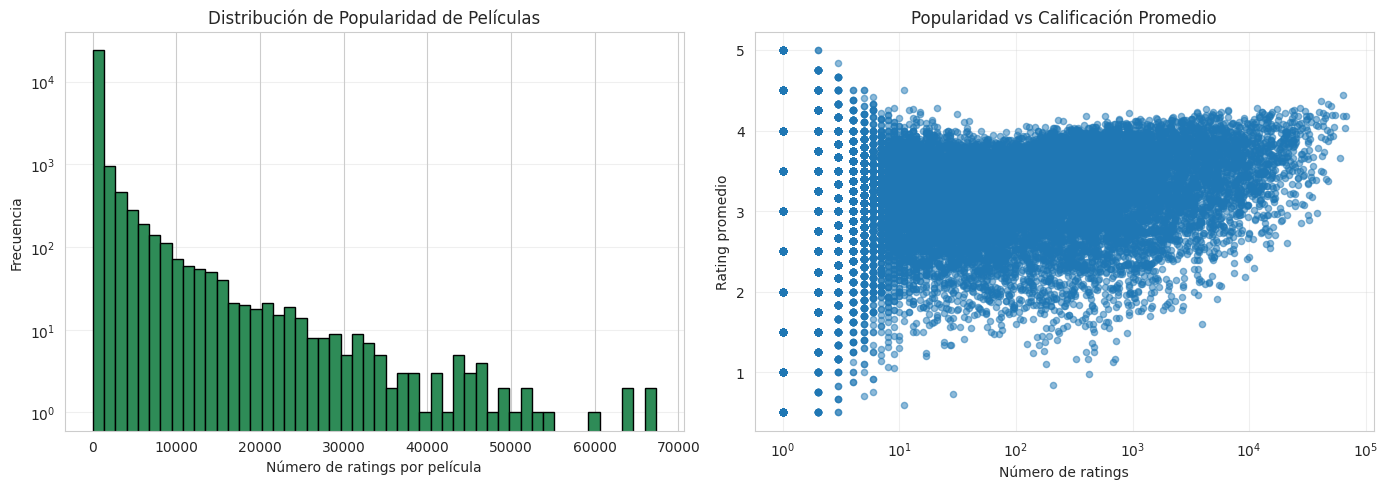

- La popularidad también sigue cola larga: pocas películas concentran gran parte de los ratings.
- No se observa una relación lineal fuerte entre popularidad y rating promedio; hay películas populares con promedio moderado.


In [10]:
# Análisis de ratings por película
print("ANÁLISIS DE RATINGS POR PELÍCULA\n")

# Unir ratings con información de películas
ratings_with_movie = ratings_dedupe.join(
    movies_dedupe.select("movieId", "title"),
    on="movieId",
    how="inner"
)

# Contar ratings por película
ratings_per_movie = ratings_dedupe.groupBy("movieId").agg(
    count("*").alias("num_ratings"),
    avg("rating").alias("avg_rating")
).join(
    movies_dedupe.select("movieId", "title"),
    on="movieId",
    how="inner"
)

# Estadísticas
movie_stats = ratings_per_movie.select(
    count("*").alias("Num_Películas"),
    avg("num_ratings").alias("Media_Ratings"),
    stddev("num_ratings").alias("Desv_Est"),
    min("num_ratings").alias("Min"),
    max("num_ratings").alias("Max"),
    percentile_approx("num_ratings", 0.5).alias("Mediana")
).collect()[0]

print(f"Número de películas: {int(movie_stats['Num_Películas']):,}")
print(f"Media de ratings por película: {movie_stats['Media_Ratings']:.2f}")
print(f"Desviación estándar: {movie_stats['Desv_Est']:.2f}")
print(f"Mínimo: {int(movie_stats['Min'])}")
print(f"Máximo: {int(movie_stats['Max'])}")
print(f"Mediana: {int(movie_stats['Mediana'])}")

# TOP 10 películas más calificadas
print("\nTOP 10 PELÍCULAS MÁS CALIFICADAS:")
top_movies = ratings_per_movie.orderBy(desc("num_ratings")).limit(10)
for row in top_movies.collect():
    print(f"  {row['title']}: {row['num_ratings']} ratings (avg: {row['avg_rating']:.2f})")

# Películas menos calificadas
print("\nTOP 10 PELÍCULAS MENOS CALIFICADAS:")
least_movies = ratings_per_movie.orderBy("num_ratings").limit(10)
for row in least_movies.collect():
    print(f"  {row['title']}: {row['num_ratings']} ratings")

# Gráficas
ratings_per_movie_pd = ratings_per_movie.toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de ratings por película
axes[0].hist(ratings_per_movie_pd['num_ratings'], bins=50, color='seagreen', edgecolor='black')
axes[0].set_xlabel('Número de ratings por película')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de Popularidad de Películas')
axes[0].set_yscale('log')
axes[0].grid(axis='y', alpha=0.3)

# Scatter: num_ratings vs avg_rating
axes[1].scatter(ratings_per_movie_pd['num_ratings'], 
                ratings_per_movie_pd['avg_rating'], 
                alpha=0.5, s=20)
axes[1].set_xlabel('Número de ratings')
axes[1].set_ylabel('Rating promedio')
axes[1].set_title('Popularidad vs Calificación Promedio')
axes[1].set_xscale('log')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("- La popularidad también sigue cola larga: pocas películas concentran gran parte de los ratings.")
print("- No se observa una relación lineal fuerte entre popularidad y rating promedio; hay películas populares con promedio moderado.")


### Paso 4: Análisis de géneros

ANÁLISIS DE GÉNEROS

PELÍCULAS POR GÉNERO (TOP 15):
  Drama: 13344 películas
  Comedy: 8374 películas
  Thriller: 4178 películas
  Romance: 4127 películas
  Action: 3520 películas
  Crime: 2939 películas
  Horror: 2611 películas
  Documentary: 2471 películas
  Adventure: 2329 películas
  Sci-Fi: 1743 películas
  Mystery: 1514 películas
  Fantasy: 1412 películas
  War: 1194 películas
  Children: 1139 películas
  Musical: 1036 películas

RATINGS POR GÉNERO (TOP 15):


  Drama: 8,857,853 ratings
  Comedy: 7,502,234 ratings
  Action: 5,614,208 ratings
  Thriller: 5,313,506 ratings
  Adventure: 4,380,351 ratings
  Romance: 3,802,002 ratings
  Crime: 3,298,335 ratings
  Sci-Fi: 3,150,141 ratings
  Fantasy: 2,111,403 ratings
  Children: 1,669,249 ratings
  Mystery: 1,557,282 ratings
  Horror: 1,482,737 ratings
  Animation: 1,140,476 ratings
  War: 1,048,618 ratings
  Musical: 870,915 ratings


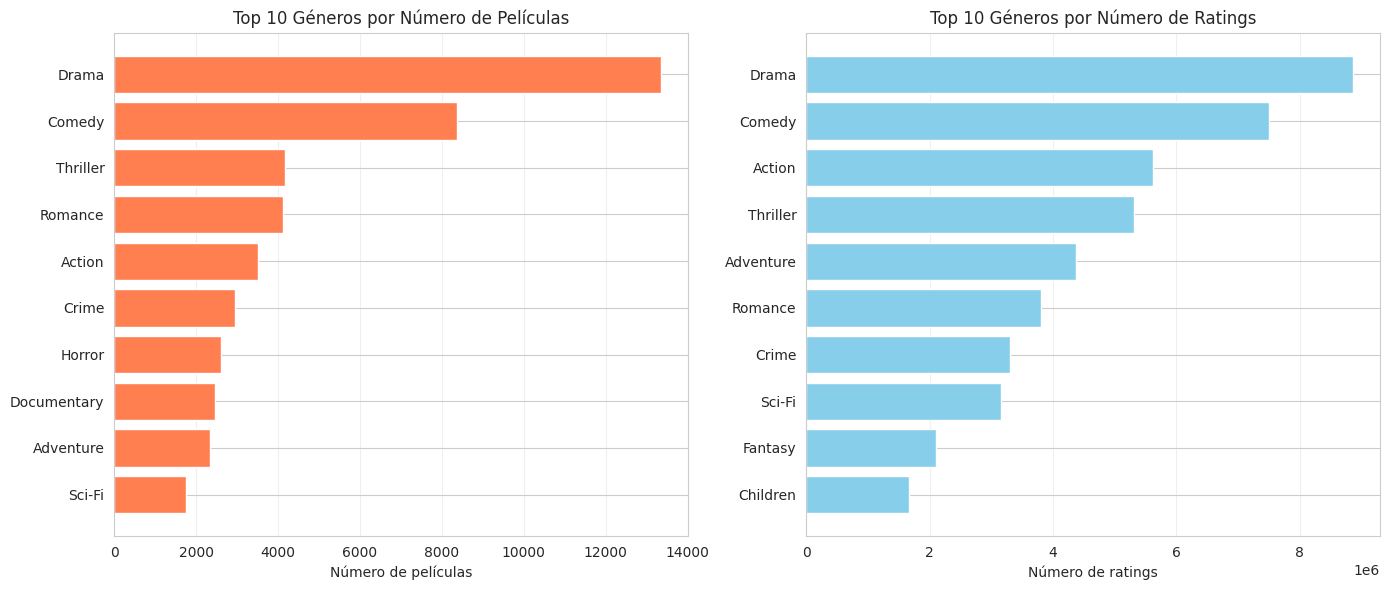

- Algunos géneros concentran mucho volumen tanto de catálogo como de interacción de usuarios.
- La distribución no es uniforme: los géneros dominantes pueden sesgar análisis de similitud y recomendaciones.


In [11]:
# Análisis de géneros
print("ANÁLISIS DE GÉNEROS\n")

# Separar géneros (están separados por | en movies.csv)
from pyspark.sql.functions import split, explode

movies_with_genres = movies_dedupe.select(
    "movieId",
    "title",
    explode(split(col("genres"), "\\|")).alias("genre")
)

# Contar películas por género
genre_movie_counts = movies_with_genres.groupBy("genre").agg(count("*").alias("num_movies")).orderBy(desc("num_movies"))

print("PELÍCULAS POR GÉNERO (TOP 15):")
for row in genre_movie_counts.limit(15).collect():
    print(f"  {row['genre']}: {row['num_movies']} películas")

# Contar ratings por género
ratings_with_genres = ratings_dedupe.join(
    movies_with_genres,
    on="movieId",
    how="inner"
)

genre_rating_counts = ratings_with_genres.groupBy("genre").agg(count("*").alias("num_ratings")).orderBy(desc("num_ratings"))

print("\nRATINGS POR GÉNERO (TOP 15):")
for row in genre_rating_counts.limit(15).collect():
    print(f"  {row['genre']}: {row['num_ratings']:,} ratings")

# Gráficas
genre_movie_pd = genre_movie_counts.toPandas()
genre_rating_pd = genre_rating_counts.toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top 10 géneros por número de películas
genre_movie_top = genre_movie_pd.head(10)
axes[0].barh(genre_movie_top['genre'], genre_movie_top['num_movies'], color='coral')
axes[0].set_xlabel('Número de películas')
axes[0].set_title('Top 10 Géneros por Número de Películas')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Top 10 géneros por número de ratings
genre_rating_top = genre_rating_pd.head(10)
axes[1].barh(genre_rating_top['genre'], genre_rating_top['num_ratings'], color='skyblue')
axes[1].set_xlabel('Número de ratings')
axes[1].set_title('Top 10 Géneros por Número de Ratings')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("- Algunos géneros concentran mucho volumen tanto de catálogo como de interacción de usuarios.")
print("- La distribución no es uniforme: los géneros dominantes pueden sesgar análisis de similitud y recomendaciones.")


### Paso 5: Análisis de Sparsity (Densidad de la Matriz Usuario-Película)

ANÁLISIS DE SPARSITY



Usuarios únicos: 138,493
Películas únicas: 26,744
Ratings totales: 20,000,263
Posibles ratings: 3,703,856,792

Densidad: 0.5400%
Sparsity: 99.4600%

Interpretación:
- Solo el 0.5400% de la matriz está lleno
- El 99.4600% de la matriz está vacía (no hay rating)
- En promedio, cada usuario ha calificado 144.41 de 26,744 películas
- En promedio, cada película ha sido calificada por 747.84 de 138,493 usuarios


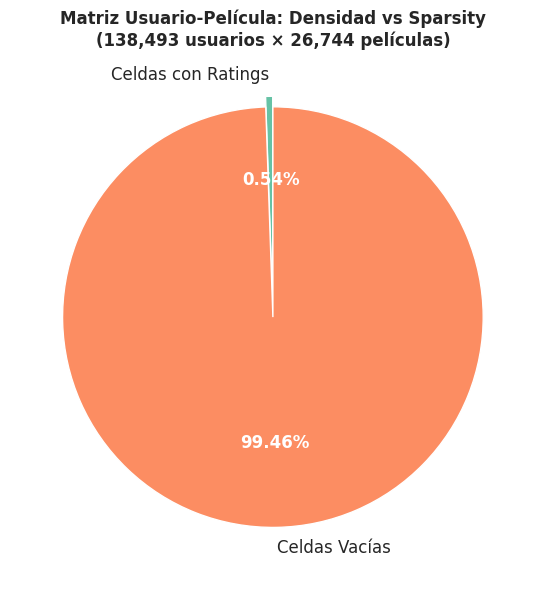

- El sistema opera sobre una matriz extremadamente dispersa, lo que justifica métodos aproximados como MinHash y LSH.
- La baja densidad implica que comparar todas las parejas de películas de forma exacta es costoso y poco escalable.


In [12]:
# Análisis de sparsity
print("ANÁLISIS DE SPARSITY\n")

# Contar usuarios y películas únicos
num_users = ratings_dedupe.select("userId").distinct().count()
num_movies = ratings_dedupe.select("movieId").distinct().count()
num_ratings = ratings_dedupe.count()

# Calcular densidad
possible_ratings = num_users * num_movies
density = (num_ratings / possible_ratings) * 100
sparsity = 100 - density

print(f"Usuarios únicos: {num_users:,}")
print(f"Películas únicas: {num_movies:,}")
print(f"Ratings totales: {num_ratings:,}")
print(f"Posibles ratings: {possible_ratings:,}")
print(f"\nDensidad: {density:.4f}%")
print(f"Sparsity: {sparsity:.4f}%")

print(f"\nInterpretación:")
print(f"- Solo el {density:.4f}% de la matriz está lleno")
print(f"- El {sparsity:.4f}% de la matriz está vacía (no hay rating)")
print(f"- En promedio, cada usuario ha calificado {num_ratings/num_users:.2f} de {num_movies:,} películas")
print(f"- En promedio, cada película ha sido calificada por {num_ratings/num_movies:.2f} de {num_users:,} usuarios")

# Visualización
fig, ax = plt.subplots(figsize=(8, 6))
labels = ['Celdas con Ratings', 'Celdas Vacías']
sizes = [density, sparsity]
colors = ['#66c2a5', '#fc8d62']
explode = (0.05, 0)

wedges, texts, autotexts = ax.pie(sizes, labels=labels, colors=colors, autopct='%1.2f%%',
                                    explode=explode, startangle=90, textprops={'fontsize': 12})
ax.set_title(f'Matriz Usuario-Película: Densidad vs Sparsity\n({num_users:,} usuarios × {num_movies:,} películas)', 
             fontsize=12, fontweight='bold')

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

plt.tight_layout()
plt.show()

print("- El sistema opera sobre una matriz extremadamente dispersa, lo que justifica métodos aproximados como MinHash y LSH.")
print("- La baja densidad implica que comparar todas las parejas de películas de forma exacta es costoso y poco escalable.")


---

# PARTE II: PROCESAMIENTO DISTRIBUIDO CON SPARK

## Introducción a la Parte II

En esta sección demostramos el poder del procesamiento distribuido con Spark para operaciones sobre datos masivos:

1. **Contar ratings:** Por película y por usuario usando operaciones distribuidas
2. **Ranking de popularidad:** Identificar las películas más calificadas (top 20)
3. **Comparativa de rendimiento:** RDDs vs DataFrames/Spark SQL
4. **Visualización:** Presentar resultados en tablas y gráficas

---

## Paso 1: Contar ratings por película y usuario (DataFrames)

In [13]:
# Contar ratings por película usando DataFrames
print("CONTEO DISTRIBUIDO CON SPARK DATAFRAMES\n")

# Método 1: DataFrames/Spark SQL (Recomendado para grandes volúmenes)
print("Método 1: Spark SQL (Optimizado para datasets masivos)")
print("-" * 60)

start_time = time.time()

# Crear tabla temporal
ratings_dedupe.createOrReplaceTempView("ratings_temp")
movies_dedupe.createOrReplaceTempView("movies_temp")

# Contar ratings por película usando SQL
top_movies_sql = spark.sql("""
    SELECT 
        m.movieId,
        m.title,
        COUNT(r.rating) as num_ratings,
        ROUND(AVG(r.rating), 2) as avg_rating
    FROM ratings_temp r
    JOIN movies_temp m ON r.movieId = m.movieId
    GROUP BY m.movieId, m.title
    ORDER BY num_ratings DESC
    LIMIT 20
""")

dataframe_time = time.time() - start_time

print(f"\nTop 20 películas por número de ratings (Spark SQL):\n")
top_movies_sql.show(20, truncate=False)
print(f"Tiempo de ejecución: {dataframe_time:.4f} segundos\n")

# Guardar resultados para comparación posterior
top_movies_sql_results = top_movies_sql.collect()

CONTEO DISTRIBUIDO CON SPARK DATAFRAMES

Método 1: Spark SQL (Optimizado para datasets masivos)
------------------------------------------------------------

Top 20 películas por número de ratings (Spark SQL):



+-------+-----------------------------------------------------+-----------+----------+
|movieId|title                                                |num_ratings|avg_rating|
+-------+-----------------------------------------------------+-----------+----------+
|296    |Pulp Fiction (1994)                                  |67310      |4.17      |
|356    |Forrest Gump (1994)                                  |66172      |4.03      |
|318    |Shawshank Redemption, The (1994)                     |63366      |4.45      |
|593    |Silence of the Lambs, The (1991)                     |63299      |4.18      |
|480    |Jurassic Park (1993)                                 |59715      |3.66      |
|260    |Star Wars: Episode IV - A New Hope (1977)            |54502      |4.19      |
|110    |Braveheart (1995)                                    |53769      |4.04      |
|589    |Terminator 2: Judgment Day (1991)                    |52244      |3.93      |
|2571   |Matrix, The (1999)                

## Paso 2: Comparativa RDDs vs DataFrames/Spark SQL

In [14]:
# Método 2: RDDs (Estilo MapReduce - más bajo nivel)
print("\nMétodo 2: RDDs (MapReduce tradicional)")
print("-" * 60)

start_time = time.time()

# Convertir a RDD
ratings_rdd = ratings_dedupe.rdd

# Extraer (movieId, 1) para cada rating
movie_ratings_rdd = ratings_rdd.map(lambda x: (x['movieId'], 1))

# Contar ratings por película usando reduceByKey (MapReduce)
movie_counts_rdd = movie_ratings_rdd.reduceByKey(lambda a, b: a + b)

# Ordenar por count descendente y obtener top 20
top_20_rdd = movie_counts_rdd.top(20, key=lambda x: x[1])

rdd_time = time.time() - start_time

print(f"\nTop 20 películas por número de ratings (RDD):")
print("movieId | num_ratings")
print("-" * 30)
for movie_id, count in top_20_rdd:
    print(f"{movie_id:<7} | {count}")
print(f"\nTiempo de ejecución: {rdd_time:.4f} segundos")

# Comparativa
print("\n" + "=" * 60)
print("COMPARATIVA DE RENDIMIENTO")
print("=" * 60)
print(f"DataFrames/Spark SQL: {dataframe_time:.4f} segundos")
print(f"RDDs (MapReduce):     {rdd_time:.4f} segundos")
print(f"Speedup (SQL/RDD):    {rdd_time/dataframe_time:.2f}x")
print("\nConclusión:")
print("→ Spark SQL es más eficiente gracias al query optimizer")
print("→ RDDs son más flexibles pero requieren más optimización manual")
print("→ Para operaciones analíticas estándar: usar DataFrames/SQL")


Método 2: RDDs (MapReduce tradicional)
------------------------------------------------------------



Top 20 películas por número de ratings (RDD):
movieId | num_ratings
------------------------------
296     | 67310
356     | 66172
318     | 63366
593     | 63299
480     | 59715
260     | 54502
110     | 53769
589     | 52244
2571    | 51334
527     | 50054
1       | 49695
457     | 49581
150     | 47777
780     | 47048
50      | 47006
1210    | 46839
592     | 46054
1196    | 45313
2858    | 44987
32      | 44980

Tiempo de ejecución: 26.5080 segundos

COMPARATIVA DE RENDIMIENTO
DataFrames/Spark SQL: 0.2839 segundos
RDDs (MapReduce):     26.5080 segundos
Speedup (SQL/RDD):    93.39x

Conclusión:
→ Spark SQL es más eficiente gracias al query optimizer
→ RDDs son más flexibles pero requieren más optimización manual
→ Para operaciones analíticas estándar: usar DataFrames/SQL


## Paso 3: Visualización del ranking de popularidad

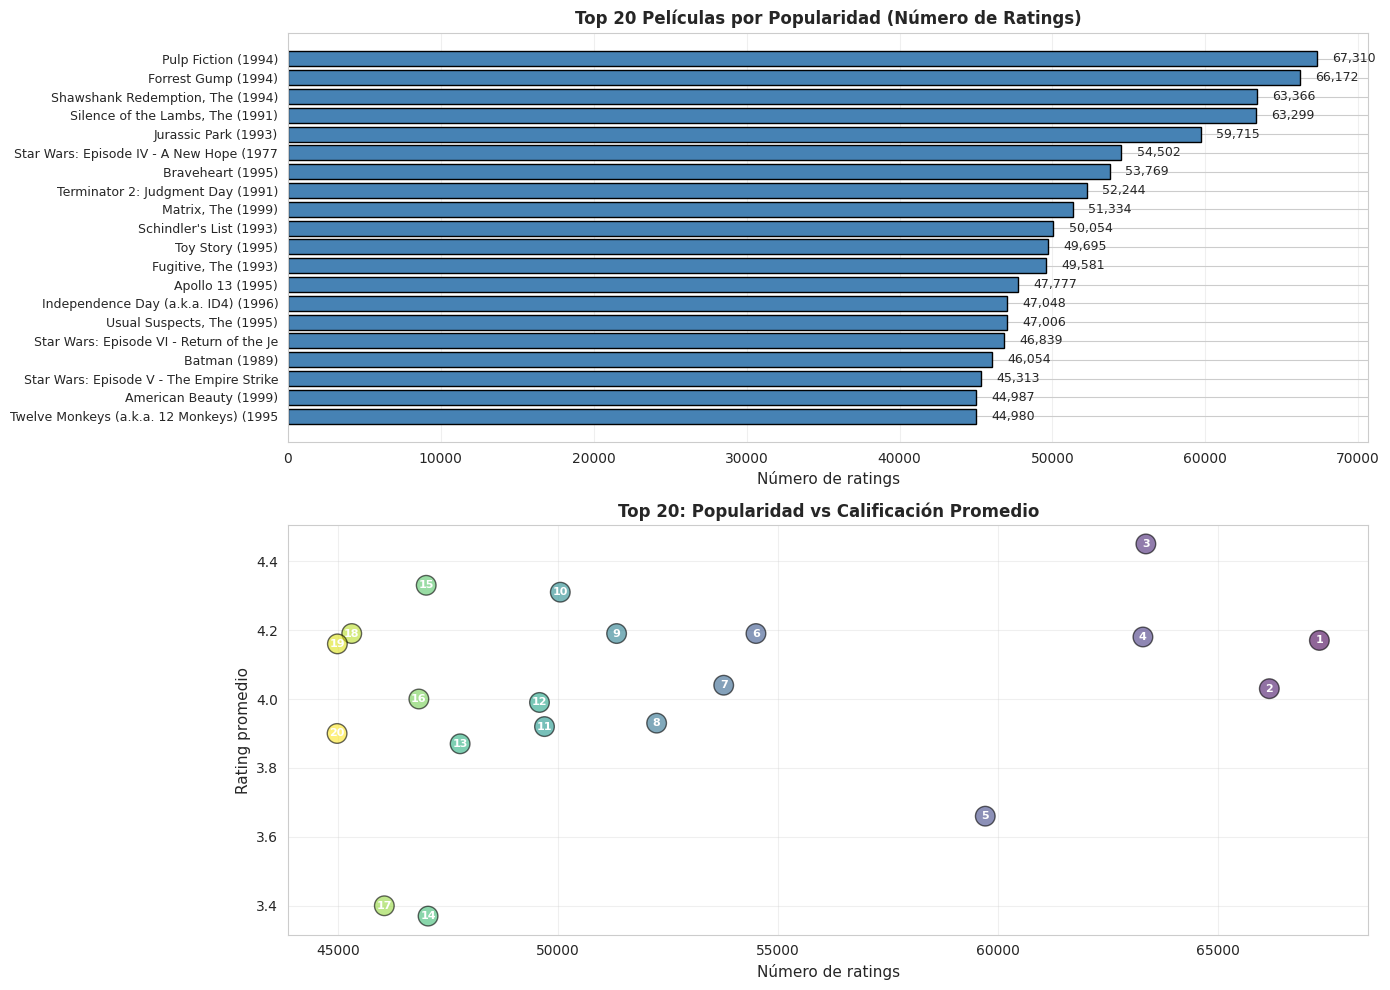

✓ Ranking de popularidad visualizado


In [15]:
# Preparar datos para visualización
top_movies_df = top_movies_sql.toPandas()
top_movies_df['title'] = top_movies_df['title'].str[:40]  # Truncar títulos largos

# Crear gráficas
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Gráfica 1: Número de ratings (barras horizontales)
axes[0].barh(range(len(top_movies_df)), top_movies_df['num_ratings'], color='steelblue', edgecolor='black')
axes[0].set_yticks(range(len(top_movies_df)))
axes[0].set_yticklabels(top_movies_df['title'], fontsize=9)
axes[0].set_xlabel('Número de ratings', fontsize=11)
axes[0].set_title('Top 20 Películas por Popularidad (Número de Ratings)', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Agregar valores en las barras
for i, v in enumerate(top_movies_df['num_ratings']):
    axes[0].text(v + 1000, i, f'{int(v):,}', va='center', fontsize=9)

# Gráfica 2: Rating promedio vs Número de ratings (scatter)
scatter = axes[1].scatter(top_movies_df['num_ratings'], 
                          top_movies_df['avg_rating'],
                          s=200, alpha=0.6, c=range(len(top_movies_df)), 
                          cmap='viridis', edgecolor='black', linewidth=1)
axes[1].set_xlabel('Número de ratings', fontsize=11)
axes[1].set_ylabel('Rating promedio', fontsize=11)
axes[1].set_title('Top 20: Popularidad vs Calificación Promedio', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Añadir etiquetas en los puntos
for idx, row in top_movies_df.iterrows():
    axes[1].annotate(str(idx+1), (row['num_ratings'], row['avg_rating']),
                     fontsize=8, ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Ranking de popularidad visualizado")

---

# PARTE III: SIMILITUD, MINHASHING Y LSH

## Introducción a la Parte III

En esta parte implementamos técnicas avanzadas para encontrar películas similares:

### Conceptos Clave

**1. Similitud de Jaccard:**

**2. MinHashing (Estimación de Jaccard):**

**3. Locality Sensitive Hashing (LSH):**

### Representaciones posibles

**Opción A - Usuarios:** Cada película = conjunto de usuarios que la calificaron positivamente

**Opción B - Tags:** Cada película = conjunto de tags asignados

**Opción C - Combinada:** Explorar ambas

---

## 3.1 Estrategia de Representación

En este proyecto usaremos **Opción A: Representación por Usuarios** porque:
- Los ratings binarios (like/dislike) dan conjuntos claros y bien definidos
- La densidad de usuarios es suficiente para encontrar patrones
- Es directamente aplicable a sistemas de recomendación colaborativos

### Paso 1: Preparar datos - Crear conjuntos de usuarios por película (representación binaria)

In [16]:
# Crear representación: cada película = conjunto de usuarios con rating positivo (binary_rating = 1)
print("CREANDO REPRESENTACIÓN POR USUARIOS\n")
print("=" * 70)

# Filtrar solo ratings positivos (like = 1)
positive_ratings = ratings_binary.filter(col("binary_rating") == 1)

# Agrupar usuarios por película
movies_users = positive_ratings.groupBy("movieId").agg(
    collect_list("userId").alias("user_set")
).join(
    movies_dedupe.select("movieId", "title"),
    on="movieId",
    how="inner"
)

# Mostrar ejemplos
print("Representación: Cada película como conjunto de usuarios que la calificaron positivamente\n")
print("Ejemplos:")
example_movies = movies_users.limit(5).collect()
for row in example_movies:
    user_list = sorted(row['user_set'])[:10]  # Mostrar solo los primeros 10
    print(f"\nMovieId: {row['movieId']}")
    print(f"Title: {row['title']}")
    print(f"Usuarios (primeros 10): {user_list}")
    print(f"Total de usuarios: {len(row['user_set'])}")

# Guardar como tabla para usar después
movies_users.createOrReplaceTempView("movies_users_view")

print(f"\n✓ Se crearon {movies_users.count()} representaciones de películas")

CREANDO REPRESENTACIÓN POR USUARIOS

Representación: Cada película como conjunto de usuarios que la calificaron positivamente

Ejemplos:



MovieId: 31
Title: Dangerous Minds (1995)
Usuarios (primeros 10): [29, 42, 57, 60, 61, 127, 209, 279, 294, 298]
Total de usuarios: 3967

MovieId: 65
Title: Bio-Dome (1996)
Usuarios (primeros 10): [204, 251, 422, 768, 850, 1099, 1281, 1505, 1539, 1540]
Total de usuarios: 941

MovieId: 85
Title: Angels and Insects (1995)
Usuarios (primeros 10): [41, 208, 310, 324, 375, 443, 603, 685, 717, 741]
Total de usuarios: 1509

MovieId: 137
Title: Man of the Year (1995)
Usuarios (primeros 10): [1667, 4009, 4201, 5292, 7054, 7273, 8580, 10321, 10732, 15302]
Total de usuarios: 90

MovieId: 251
Title: Hunted, The (1995)
Usuarios (primeros 10): [461, 1021, 3202, 4706, 5314, 5494, 5640, 6266, 6314, 6460]
Total de usuarios: 129



✓ Se crearon 22884 representaciones de películas


---

## 3.2 Similitud Exacta vs Aproximada (MinHashing)

### Paso 2: Implementar similitud de Jaccard exacta (para muestra representativa)

In [17]:
def jaccard_similarity(set1, set2):
    """
    Calcula la similitud de Jaccard entre dos conjuntos.
    J(A,B) = |A ∩ B| / |A ∪ B|
    """
    set1_py = set(set1)
    set2_py = set(set2)

    intersection = len(set1_py & set2_py)
    union = len(set1_py | set2_py)

    if union == 0:
        return 0.0
    return intersection / union

# Tomar muestra para calculo exacto (O(n^2) sobre sample_size)
print("SIMILITUD DE JACCARD EXACTA (Muestra configurable)\n")
print("=" * 70)

# SAMPLE_SIZE puede ser porcentaje (0-1) o un entero
if isinstance(SAMPLE_SIZE, float) and SAMPLE_SIZE <= 1:
    total_movies = movies_users.count()
    sample_size = int(total_movies * SAMPLE_SIZE)
else:
    sample_size = int(SAMPLE_SIZE)

import builtins
sample_size = builtins.max(sample_size, 1)

sample_movies = movies_users.limit(sample_size).collect()

# Convertir a diccionario para acceso rapido
movie_dict = {row["movieId"]: row["user_set"] for row in sample_movies}

# Calcular similitud de Jaccard para todos los pares
jaccard_pairs = []

for i, movie1_id in enumerate(movie_dict.keys()):
    for j, movie2_id in enumerate(list(movie_dict.keys())[i + 1 :], start=i + 1):
        jaccard_sim = jaccard_similarity(movie_dict[movie1_id], movie_dict[movie2_id])
        if jaccard_sim > 0:  # Solo guardar pares con similitud > 0
            jaccard_pairs.append(
                {
                    "movie1_id": movie1_id,
                    "movie2_id": movie2_id,
                    "jaccard_sim": jaccard_sim,
                }
            )

# Ordenar por similitud descendente
jaccard_pairs_sorted = sorted(jaccard_pairs, key=lambda x: x["jaccard_sim"], reverse=True)

print(f"Tamaño de muestra usado: {sample_size}")
print(f"Número total de pares con similitud > 0: {len(jaccard_pairs)}")
print("\nTop 15 pares de peliculas mas similares (Jaccard exacto):\n")
print(f"{'Movie1':<6} | {'Movie2':<6} | {'Jaccard':<10}")
print("-" * 30)

for pair in jaccard_pairs_sorted[:15]:
    print(f"{pair['movie1_id']:<6} | {pair['movie2_id']:<6} | {pair['jaccard_sim']:.4f}")

# Guardar para comparar con MinHash despues
jaccard_exact_results = {
    f"{pair['movie1_id']}_{pair['movie2_id']}": pair["jaccard_sim"]
    for pair in jaccard_pairs_sorted
}


SIMILITUD DE JACCARD EXACTA (Muestra configurable)



Tamaño de muestra usado: 2288
Número total de pares con similitud > 0: 774119

Top 15 pares de peliculas mas similares (Jaccard exacto):

Movie1 | Movie2 | Jaccard   
------------------------------
36312  | 118193 | 1.0000
61314  | 74127  | 1.0000
61314  | 65518  | 1.0000
75979  | 131011 | 1.0000
80152  | 32357  | 1.0000
86337  | 108936 | 1.0000
86337  | 87511  | 1.0000
86337  | 98304  | 1.0000
86337  | 73967  | 1.0000
86337  | 92027  | 1.0000
86337  | 108265 | 1.0000
89537  | 117374 | 1.0000
89537  | 125628 | 1.0000
89537  | 43997  | 1.0000
89537  | 86839  | 1.0000


### Paso 3: Implementar MinHashing

In [18]:
import random
import builtins

def minhash_signature(s, hash_funcs, max_val):
    signature = []
    for a, b in hash_funcs:
        min_hash = float('inf')
        for x in s:
            h = (a * x + b) % max_val
            if h < min_hash:
                min_hash = h
        signature.append(min_hash)
    return signature

def jaccard_from_minhash(sig1, sig2, num_hashes):

    matches = builtins.sum(1 for i in range(num_hashes) if sig1[i] == sig2[i])
    return matches / num_hashes

def hash_funcs(max_val,num_hashes):
    return [
    (random.randint(1, max_val), random.randint(0, max_val))
    for _ in range(num_hashes)
]

print("MINHASHING (Estimación aproximada de Jaccard)\n")
print("=" * 70)

# Calcular firmas MinHash para la muestra
num_hash_functions = NUM_HASH_FUNCTIONS
max_val = 1000000000

print(f"Calculando firmas MinHash (k={num_hash_functions}) para {len(sample_movies)} películas...\n")

hash_funtions = hash_funcs(max_val,num_hash_functions)

minhash_sigs = {}
for movie in sample_movies:
    movie_id = movie['movieId']
    sig = minhash_signature(movie['user_set'],hash_funtions,max_val)
    minhash_sigs[movie_id] = sig

print(f"✓ Firmas MinHash calculadas\n")

# Calcular similitud aproximada usando MinHash para los mismos pares
minhash_pairs = []

for i, movie1_id in enumerate(minhash_sigs.keys()):
    for j, movie2_id in enumerate(list(minhash_sigs.keys())[i+1:], start=i+1):
        minhash_sim = jaccard_from_minhash(minhash_sigs[movie1_id], minhash_sigs[movie2_id],num_hash_functions)
        
        # Obtener similitud exacta para comparación
        pair_key = f"{movie1_id}_{movie2_id}"
        exact_sim = jaccard_exact_results.get(pair_key, 0)
        
        if exact_sim > 0 or minhash_sim > 0:
            minhash_pairs.append({
                'movie1_id': movie1_id,
                'movie2_id': movie2_id,
                'minhash_sim': minhash_sim,
                'exact_sim': exact_sim,
                'error': builtins.abs(minhash_sim - exact_sim)
            })

# Ordenar por similitud aproximada
minhash_pairs_sorted = sorted(minhash_pairs, key=lambda x: x['minhash_sim'], reverse=True)

print(f"Top 15 pares según MinHash (con error vs exacto):\n")
print(f"{'Movie1':<6} | {'Movie2':<6} | {'MinHash':<10} | {'Exacto':<10} | {'Error':<10}")
print("-" * 55)

for pair in minhash_pairs_sorted[:15]:
    print(f"{pair['movie1_id']:<6} | {pair['movie2_id']:<6} | {pair['minhash_sim']:.4f} | {pair['exact_sim']:.4f} | {pair['error']:.4f}")

MINHASHING (Estimación aproximada de Jaccard)

Calculando firmas MinHash (k=1200) para 2288 películas...

✓ Firmas MinHash calculadas

Top 15 pares según MinHash (con error vs exacto):

Movie1 | Movie2 | MinHash    | Exacto     | Error     
-------------------------------------------------------
36312  | 118193 | 1.0000 | 1.0000 | 0.0000
61314  | 74127  | 1.0000 | 1.0000 | 0.0000
61314  | 65518  | 1.0000 | 1.0000 | 0.0000
75979  | 131011 | 1.0000 | 1.0000 | 0.0000
80152  | 32357  | 1.0000 | 1.0000 | 0.0000
86337  | 108936 | 1.0000 | 1.0000 | 0.0000
86337  | 87511  | 1.0000 | 1.0000 | 0.0000
86337  | 98304  | 1.0000 | 1.0000 | 0.0000
86337  | 73967  | 1.0000 | 1.0000 | 0.0000
86337  | 92027  | 1.0000 | 1.0000 | 0.0000
86337  | 108265 | 1.0000 | 1.0000 | 0.0000
89537  | 117374 | 1.0000 | 1.0000 | 0.0000
89537  | 125628 | 1.0000 | 1.0000 | 0.0000
89537  | 43997  | 1.0000 | 1.0000 | 0.0000
89537  | 86839  | 1.0000 | 1.0000 | 0.0000


### Paso 4: Comparativa Jaccard exacto vs MinHash (Análisis de error y precisión)


COMPARATIVA: JACCARD EXACTO vs MINHASH

Número de pares válidos (similitud > 0): 774119

Métricas de Error:
  • Error Absoluto Medio (MAE): 0.0019
  • Error Cuadrático Medio (RMSE): 0.0030
  • Error Máximo: 0.0542

Correlación:
  • Correlación de Pearson: 0.9955
  • P-valor: 0.0000e+00


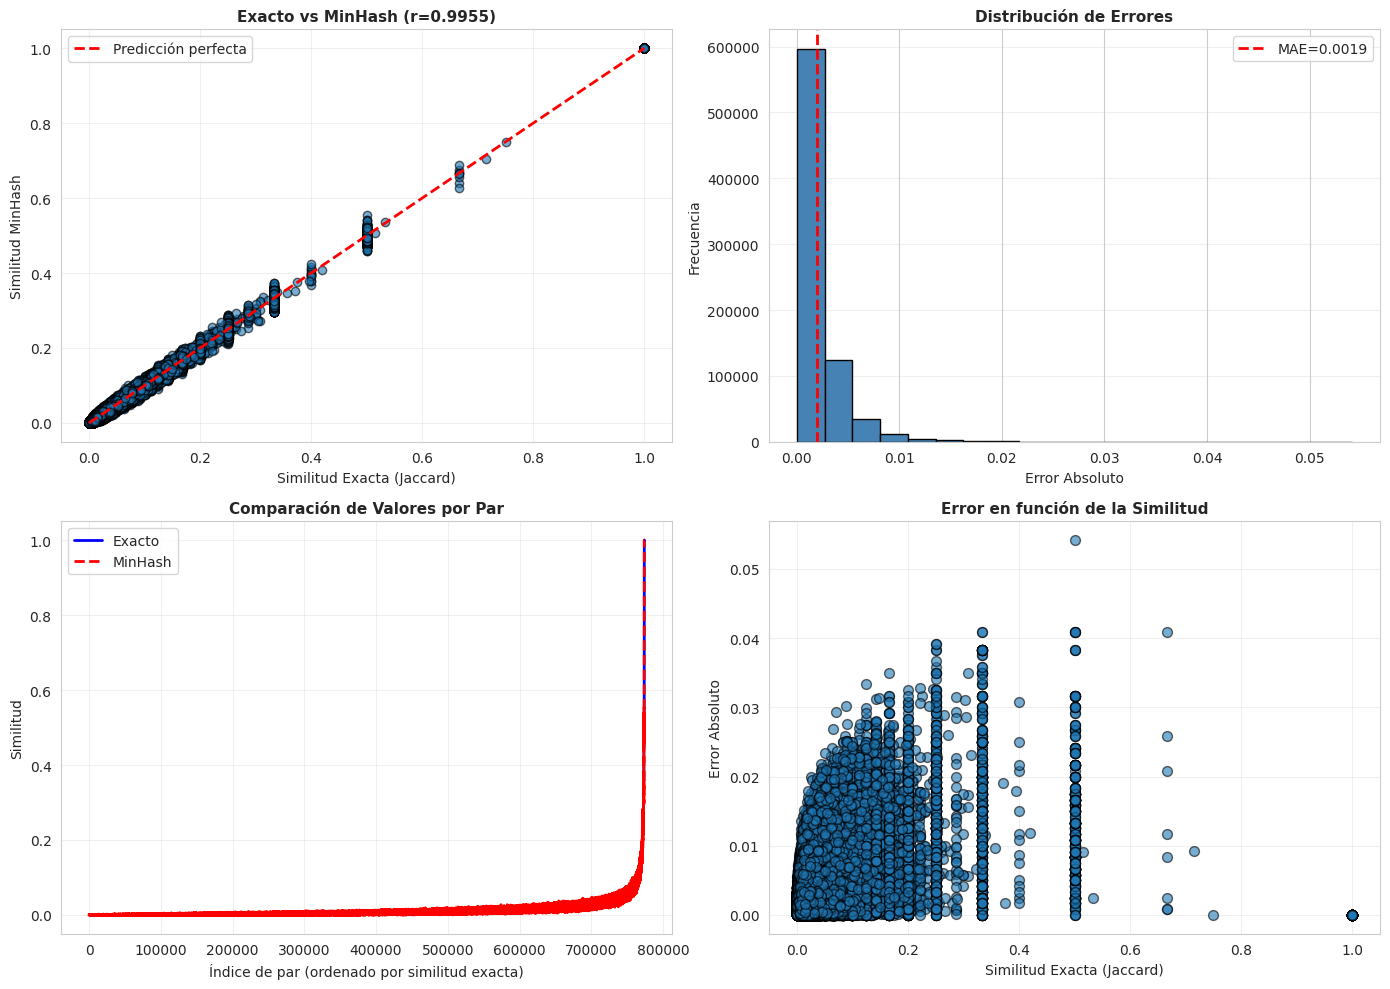

In [19]:
# Análisis de error y precisión
print("\nCOMPARATIVA: JACCARD EXACTO vs MINHASH\n")
print("=" * 70)

# Filtrar pares con similitud exacta > 0
valid_pairs = [p for p in minhash_pairs if p['exact_sim'] > 0]

if valid_pairs:
    errors = [p['error'] for p in valid_pairs]
    exact_sims = [p['exact_sim'] for p in valid_pairs]
    minhash_sims = [p['minhash_sim'] for p in valid_pairs]
    
    # Calcular métricas
    mae = np.mean(errors)  # Mean Absolute Error
    rmse = np.sqrt(np.mean([e**2 for e in errors]))  # Root Mean Square Error
    max_error = np.max(errors)
    
    # Correlación de Pearson
    if len(valid_pairs) > 1:
        pearson_corr, pearson_pval = pearsonr(exact_sims, minhash_sims)
    else:
        pearson_corr, pearson_pval = 0, 1
    
    print(f"Número de pares válidos (similitud > 0): {len(valid_pairs)}")
    print(f"\nMétricas de Error:")
    print(f"  • Error Absoluto Medio (MAE): {mae:.4f}")
    print(f"  • Error Cuadrático Medio (RMSE): {rmse:.4f}")
    print(f"  • Error Máximo: {max_error:.4f}")
    print(f"\nCorrelación:")
    print(f"  • Correlación de Pearson: {pearson_corr:.4f}")
    print(f"  • P-valor: {pearson_pval:.4e}")
    
    # Gráficas de comparativa
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Scatter: Exacto vs MinHash
    axes[0, 0].scatter(exact_sims, minhash_sims, alpha=0.6, edgecolor='black')
    axes[0, 0].plot([0, 1], [0, 1], 'r--', linewidth=2, label='Predicción perfecta')
    axes[0, 0].set_xlabel('Similitud Exacta (Jaccard)', fontsize=10)
    axes[0, 0].set_ylabel('Similitud MinHash', fontsize=10)
    axes[0, 0].set_title(f'Exacto vs MinHash (r={pearson_corr:.4f})', fontsize=11, fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Histograma de errores
    axes[0, 1].hist(errors, bins=20, color='steelblue', edgecolor='black')
    axes[0, 1].axvline(mae, color='red', linestyle='--', linewidth=2, label=f'MAE={mae:.4f}')
    axes[0, 1].set_xlabel('Error Absoluto', fontsize=10)
    axes[0, 1].set_ylabel('Frecuencia', fontsize=10)
    axes[0, 1].set_title('Distribución de Errores', fontsize=11, fontweight='bold')
    axes[0, 1].legend()
    axes[0, 1].grid(axis='y', alpha=0.3)
    
    # Similitud exacta en orden
    sorted_indices = np.argsort(exact_sims)
    axes[1, 0].plot(range(len(valid_pairs)), np.array(exact_sims)[sorted_indices], 
                    'b-', label='Exacto', linewidth=2)
    axes[1, 0].plot(range(len(valid_pairs)), np.array(minhash_sims)[sorted_indices], 
                    'r--', label='MinHash', linewidth=2)
    axes[1, 0].set_xlabel('Índice de par (ordenado por similitud exacta)', fontsize=10)
    axes[1, 0].set_ylabel('Similitud', fontsize=10)
    axes[1, 0].set_title('Comparación de Valores por Par', fontsize=11, fontweight='bold')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Error vs Similitud exacta
    axes[1, 1].scatter(exact_sims, errors, alpha=0.6, edgecolor='black', s=50)
    axes[1, 1].set_xlabel('Similitud Exacta (Jaccard)', fontsize=10)
    axes[1, 1].set_ylabel('Error Absoluto', fontsize=10)
    axes[1, 1].set_title('Error en función de la Similitud', fontsize=11, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No hay pares válidos para comparar.")

---

## 3.3 Locality Sensitive Hashing (LSH)

### Paso 5: Implementar LSH y analizar diferentes configuraciones

In [20]:
print("LSH (Locality Sensitive Hashing) - Implementación Manual\n")
print("=" * 70)

from collections import defaultdict
from itertools import combinations

def lsh_candidates(minhash_sigs, b, r):
    for sig in minhash_sigs.values():
        assert len(sig) == b * r, "La firma no coincide con b * r"

    bands = [defaultdict(list) for _ in range(b)]

    for doc_id, sig in minhash_sigs.items():
        for band_idx in range(b):
            start = band_idx * r
            end = start + r
            band_key = tuple(sig[start:end])
            bands[band_idx][band_key].append(doc_id)

    candidates = set()
    for band_idx in range(b):
        for bucket_docs in bands[band_idx].values():
            if len(bucket_docs) > 1:
                for doc1, doc2 in combinations(bucket_docs, 2):
                    candidates.add(tuple(sorted((doc1, doc2))))

    return candidates


configurations = LSH_CONFIGURATIONS

lsh_results = {}
k = num_hash_functions  # Debe coincidir con b*r
real_threshold = LSH_REAL_THRESHOLD

print(f"Número total de funciones hash: {k}")
print(f"Umbral real (ground truth): {real_threshold}")
print(f"Analizando {len(configurations)} configuraciones de LSH...\n")

# Ground truth positivo (pares realmente similares)
ground_truth_pos = set()
for pair_key, sim in jaccard_exact_results.items():
    if sim >= real_threshold:
        m1, m2 = pair_key.split("_")
        m1, m2 = int(m1), int(m2)
        ground_truth_pos.add(tuple(sorted((m1, m2))))

for b, r in configurations:
    assert b * r == k, f"Configuración inválida: {b} * {r} ≠ {k}"

    # Umbral teórico LSH (lo conservamos para tus gráficas)
    threshold = (1.0 / b) ** (1.0 / r)

    # Candidatos LSH (predicción positiva)
    candidates = lsh_candidates(minhash_sigs, b, r)
    predicted_pos = set(candidates)

    # Métricas de clasificación usando umbral REAL
    true_positives = len(predicted_pos & ground_truth_pos)
    false_positives = len(predicted_pos - ground_truth_pos)
    false_negatives = len(ground_truth_pos - predicted_pos)

    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0.0
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0.0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

    # Mantengo exactamente las llaves que usa tu bloque de gráficas
    lsh_results[(b, r)] = {
        'threshold': threshold,  # teórico (para gráfica)
        'candidates': len(candidates),
        'true_positives': true_positives,
        'false_positives': false_positives,
        'false_negatives': false_negatives,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

    print(f"Configuración (b={b}, r={r}):")
    print(f"  Umbral de similitud teórico (LSH): {threshold:.4f}")
    print(f"  Pares candidatos encontrados: {len(candidates)}")
    print(f"  Verdaderos Positivos: {true_positives}")
    print(f"  Falsos Positivos: {false_positives}")
    print(f"  Falsos Negativos: {false_negatives}")
    print(f"  Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")
    print()

LSH (Locality Sensitive Hashing) - Implementación Manual

Número total de funciones hash: 1200
Umbral real (ground truth): 0.85
Analizando 5 configuraciones de LSH...

Configuración (b=120, r=10):
  Umbral de similitud teórico (LSH): 0.6196
  Pares candidatos encontrados: 353
  Verdaderos Positivos: 309
  Falsos Positivos: 44
  Falsos Negativos: 0
  Precision: 0.8754 | Recall: 1.0000 | F1: 0.9335

Configuración (b=150, r=8):
  Umbral de similitud teórico (LSH): 0.5346
  Pares candidatos encontrados: 523
  Verdaderos Positivos: 309
  Falsos Positivos: 214
  Falsos Negativos: 0
  Precision: 0.5908 | Recall: 1.0000 | F1: 0.7428

Configuración (b=240, r=5):
  Umbral de similitud teórico (LSH): 0.3342
  Pares candidatos encontrados: 1456
  Verdaderos Positivos: 309
  Falsos Positivos: 1147
  Falsos Negativos: 0
  Precision: 0.2122 | Recall: 1.0000 | F1: 0.3501

Configuración (b=300, r=4):
  Umbral de similitud teórico (LSH): 0.2403
  Pares candidatos encontrados: 2974
  Verdaderos Positivos

### Paso 6: Utilizar LSH de Spark MLlib y comparar resultados con implementación manual

In [21]:
from pyspark.ml.linalg import Vectors
from pyspark.sql import functions as SF
from pyspark.storagelevel import StorageLevel

# ==============================
# 1) Construcción de features (sin UDF Python)
# ==============================

num_hash_tables = SPARK_LSH_NUM_HASH_TABLES

# Universo de usuarios
all_users = sorted({u for movie in sample_movies for u in movie["user_set"]})
user_to_idx = {u: i for i, u in enumerate(all_users)}
vector_dim = len(all_users)

# Crear directamente vectores dispersos en Python y pasarlos a Spark
rows = []
for movie in sample_movies:
    movie_id = int(movie["movieId"])
    user_set = movie["user_set"] or []
    idx = sorted({user_to_idx[u] for u in user_set if u in user_to_idx})
    features = Vectors.sparse(vector_dim, idx, [1.0] * len(idx))
    rows.append((movie_id, features))

df = spark.createDataFrame(rows, ["movieId", "features"]).repartition(8).persist(StorageLevel.MEMORY_AND_DISK)
_ = df.count()  # materializar cache

print("Schema final para LSH:")
df.printSchema()

# ==============================
# 2) Entrenamiento LSH
# ==============================
lsh = MinHashLSH(
    inputCol="features",
    outputCol="hashes",
    numHashTables=num_hash_tables
)
model = lsh.fit(df)
print(f"✓ Modelo MinHashLSH entrenado correctamente (numHashTables={num_hash_tables})")

# ==============================
# 3) Comparación LSH vs Jaccard real
# ==============================
threshold_distance = SPARK_APPROX_DISTANCE_THRESHOLD
real_threshold = LSH_REAL_THRESHOLD

if "jaccard_exact_results" not in globals():
    raise ValueError("No existe jaccard_exact_results en el kernel. Ejecuta primero la celda de Jaccard exacto.")

# Predichos por LSH
similar_pairs = model.approxSimilarityJoin(
    df, df,
    threshold=threshold_distance,
    distCol="dist"
)

predicted = (
    similar_pairs
    .select(
        SF.least(SF.col("datasetA")["movieId"], SF.col("datasetB")["movieId"]).alias("id1"),
        SF.greatest(SF.col("datasetA")["movieId"], SF.col("datasetB")["movieId"]).alias("id2"),
        (SF.lit(1.0) - SF.col("dist")).alias("jaccard_aprox")
    )
    .filter(SF.col("id1") < SF.col("id2"))
    .dropDuplicates(["id1", "id2"])
)

# Ground truth
gt_rows = []
for pair_key, sim in jaccard_exact_results.items():
    m1, m2 = pair_key.split("_")
    id1, id2 = sorted([int(m1), int(m2)])
    gt_rows.append((id1, id2, float(sim)))

ground_truth = (
    spark.createDataFrame(gt_rows, ["id1", "id2", "jaccard_real"])
    .dropDuplicates(["id1", "id2"])
)

predicted_pos = predicted.select("id1", "id2").withColumn("pred", SF.lit(1))
ground_truth_pos = ground_truth.filter(SF.col("jaccard_real") >= real_threshold).select("id1", "id2").withColumn("gt", SF.lit(1))

# TP/FP/FN en una sola pasada
conf = (
    predicted_pos.join(ground_truth_pos, ["id1", "id2"], "full_outer")
    .na.fill(0, ["pred", "gt"])
    .agg(
        SF.sum(SF.expr("CASE WHEN pred=1 AND gt=1 THEN 1 ELSE 0 END")).alias("tp"),
        SF.sum(SF.expr("CASE WHEN pred=1 AND gt=0 THEN 1 ELSE 0 END")).alias("fp"),
        SF.sum(SF.expr("CASE WHEN pred=0 AND gt=1 THEN 1 ELSE 0 END")).alias("fn")
    )
    .collect()[0]
)

tp = int(conf["tp"])
fp = int(conf["fp"])
fn = int(conf["fn"])

precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

# Error numérico aprox vs real
comparison = predicted.join(ground_truth, ["id1", "id2"], "inner").withColumn(
    "abs_error", SF.abs(SF.col("jaccard_aprox") - SF.col("jaccard_real"))
).withColumn(
    "sq_error", SF.pow(SF.col("jaccard_aprox") - SF.col("jaccard_real"), 2)
)

error_stats = comparison.agg(
    SF.count("*").alias("n_common_pairs"),
    SF.avg("abs_error").alias("mae"),
    SF.sqrt(SF.avg("sq_error")).alias("rmse")
).collect()[0]

print("\n=== COMPARACIÓN CONTRA JACCARD REAL ===")
print(f"Threshold real (sim): {real_threshold}")
print(f"Threshold LSH (dist): {threshold_distance}")
print(f"TP: {tp}")
print(f"FP: {fp}")
print(f"FN: {fn}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"Pares en común (para error): {error_stats['n_common_pairs']}")
print(f"MAE (sim):  {error_stats['mae'] if error_stats['mae'] is not None else 0.0:.4f}")
print(f"RMSE (sim): {error_stats['rmse'] if error_stats['rmse'] is not None else 0.0:.4f}")

print("\nTop 10 pares con mayor error absoluto:")
comparison.orderBy(SF.desc("abs_error")).select(
    "id1", "id2", "jaccard_real", "jaccard_aprox", "abs_error"
).show(10, truncate=False)

# Limpieza de cache
comparison.unpersist(blocking=False) if comparison.is_cached else None
df.unpersist(blocking=False)

Schema final para LSH:
root
 |-- movieId: long (nullable = true)
 |-- features: vector (nullable = true)

✓ Modelo MinHashLSH entrenado correctamente (numHashTables=96)



=== COMPARACIÓN CONTRA JACCARD REAL ===
Threshold real (sim): 0.85
Threshold LSH (dist): 0.3
TP: 309
FP: 2
FN: 0
Precision: 0.9936
Recall:    1.0000
F1-score:  0.9968
Pares en común (para error): 311
MAE (sim):  0.0000
RMSE (sim): 0.0000

Top 10 pares con mayor error absoluto:


+------+------+------------+-------------+---------+
|id1   |id2   |jaccard_real|jaccard_aprox|abs_error|
+------+------+------------+-------------+---------+
|93187 |93702 |1.0         |1.0          |0.0      |
|59922 |87061 |1.0         |1.0          |0.0      |
|47129 |97319 |1.0         |1.0          |0.0      |
|87061 |113478|1.0         |1.0          |0.0      |
|87061 |129847|1.0         |1.0          |0.0      |
|113721|129847|1.0         |1.0          |0.0      |
|43997 |125628|1.0         |1.0          |0.0      |
|124851|128173|1.0         |1.0          |0.0      |
|91067 |110858|1.0         |1.0          |0.0      |
|57482 |91906 |1.0         |1.0          |0.0      |
+------+------+------------+-------------+---------+
only showing top 10 rows


DataFrame[movieId: bigint, features: vector]

### Paso 6: Visualización de resultados LSH - Trade-offs

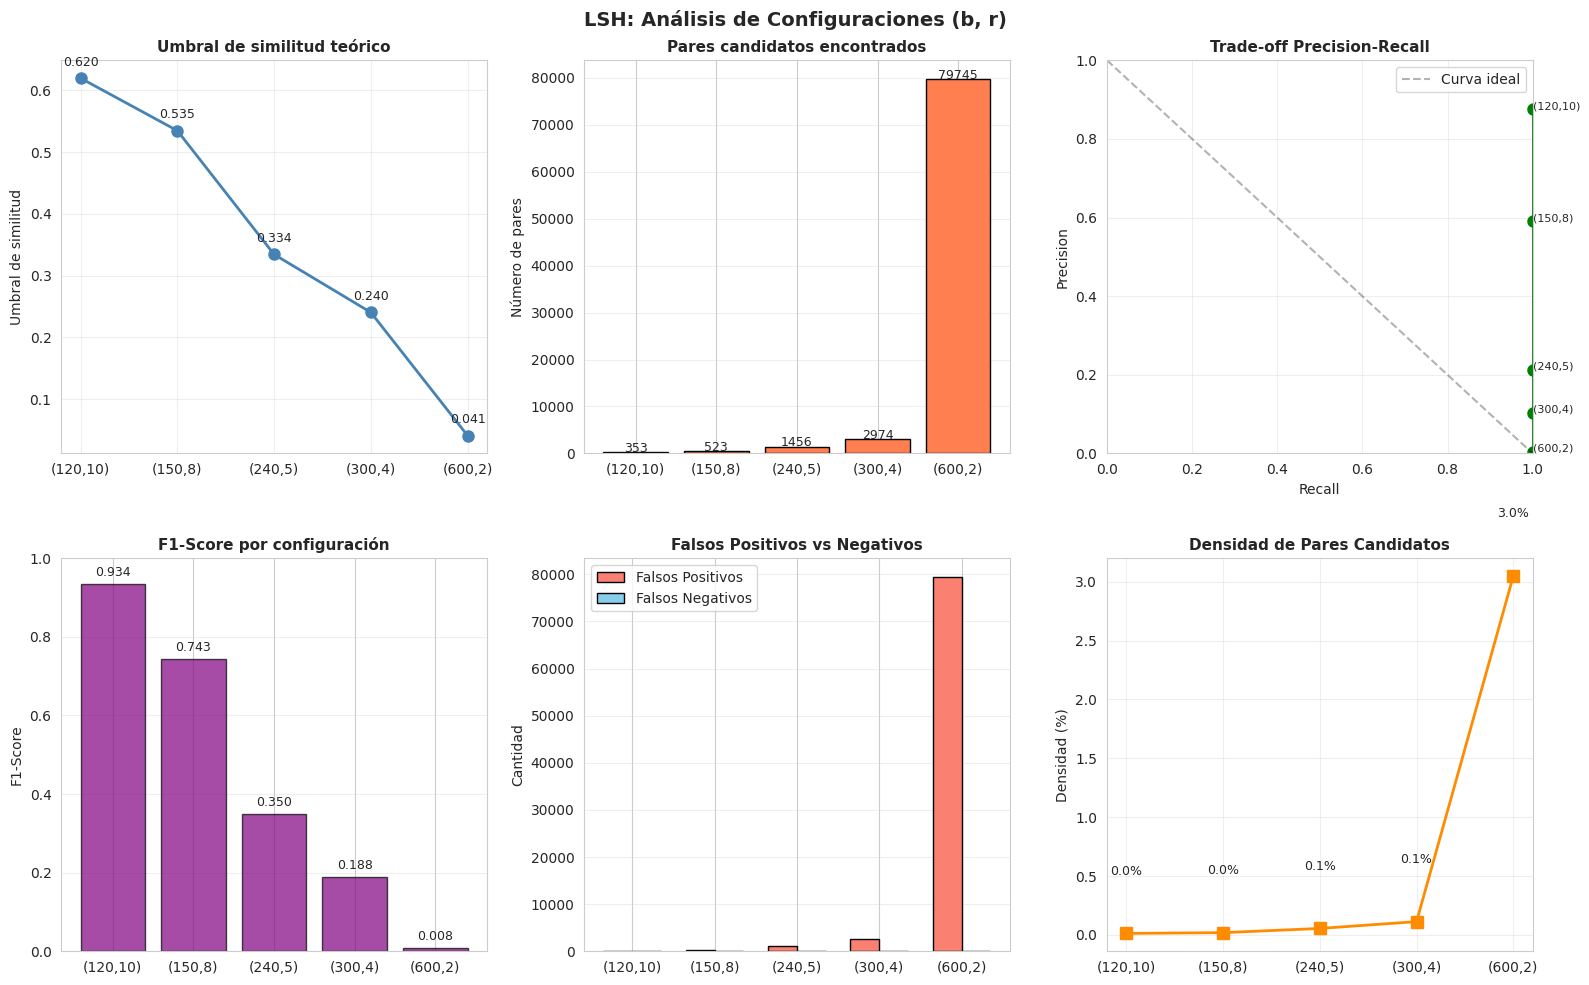

✓ Visualizaciones completadas


In [22]:
# Preparar datos para gráficas
configs_labels = [f"({b},{r})" for b, r in configurations]
thresholds = [lsh_results[(b, r)]['threshold'] for b, r in configurations]
num_candidates = [lsh_results[(b, r)]['candidates'] for b, r in configurations]
precisions = [lsh_results[(b, r)]['precision'] for b, r in configurations]
recalls = [lsh_results[(b, r)]['recall'] for b, r in configurations]
f1_scores = [lsh_results[(b, r)]['f1'] for b, r in configurations]
fps = [lsh_results[(b, r)]['false_positives'] for b, r in configurations]
fns = [lsh_results[(b, r)]['false_negatives'] for b, r in configurations]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('LSH: Análisis de Configuraciones (b, r)', fontsize=14, fontweight='bold')

# 1. Umbral de similitud teórica
axes[0, 0].plot(range(len(configurations)), thresholds, 'o-', linewidth=2, markersize=8, color='steelblue')
axes[0, 0].set_xticks(range(len(configurations)))
axes[0, 0].set_xticklabels(configs_labels)
axes[0, 0].set_ylabel('Umbral de similitud', fontsize=10)
axes[0, 0].set_title('Umbral de similitud teórico', fontsize=11, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
for i, v in enumerate(thresholds):
    axes[0, 0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)

# 2. Número de pares candidatos
axes[0, 1].bar(range(len(configurations)), num_candidates, color='coral', edgecolor='black')
axes[0, 1].set_xticks(range(len(configurations)))
axes[0, 1].set_xticklabels(configs_labels)
axes[0, 1].set_ylabel('Número de pares', fontsize=10)
axes[0, 1].set_title('Pares candidatos encontrados', fontsize=11, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(num_candidates):
    axes[0, 1].text(i, v + 50, str(v), ha='center', fontsize=9)

# 3. Precision-Recall trade-off
axes[0, 2].plot(recalls, precisions, 'o-', linewidth=2, markersize=8, color='green')
axes[0, 2].set_xlabel('Recall', fontsize=10)
axes[0, 2].set_ylabel('Precision', fontsize=10)
axes[0, 2].set_title('Trade-off Precision-Recall', fontsize=11, fontweight='bold')
axes[0, 2].set_xlim([0, 1])
axes[0, 2].set_ylim([0, 1])
axes[0, 2].plot([0, 1], [1, 0], 'k--', alpha=0.3, label='Curva ideal')
axes[0, 2].grid(True, alpha=0.3)
axes[0, 2].legend()
for i, (r, p) in enumerate(zip(recalls, precisions)):
    axes[0, 2].annotate(configs_labels[i], (r, p), fontsize=8)

# 4. F1-score por configuración
axes[1, 0].bar(range(len(configurations)), f1_scores, color='purple', edgecolor='black', alpha=0.7)
axes[1, 0].set_xticks(range(len(configurations)))
axes[1, 0].set_xticklabels(configs_labels)
axes[1, 0].set_ylabel('F1-Score', fontsize=10)
axes[1, 0].set_title('F1-Score por configuración', fontsize=11, fontweight='bold')
axes[1, 0].set_ylim([0, 1])
axes[1, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(f1_scores):
    axes[1, 0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)

# 5. Falsos Positivos vs Falsos Negativos
x = np.arange(len(configurations))
width = 0.35
axes[1, 1].bar(x - width/2, fps, width, label='Falsos Positivos', color='salmon', edgecolor='black')
axes[1, 1].bar(x + width/2, fns, width, label='Falsos Negativos', color='skyblue', edgecolor='black')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(configs_labels)
axes[1, 1].set_ylabel('Cantidad', fontsize=10)
axes[1, 1].set_title('Falsos Positivos vs Negativos', fontsize=11, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

# 6. Densidad de candidatos (pares candidatos / total de pares posibles)
total_possible_pairs = len(minhash_sigs) * (len(minhash_sigs) - 1) / 2
candidate_densities = [num_candidates[i] / total_possible_pairs * 100 for i in range(len(configurations))]
axes[1, 2].plot(range(len(configurations)), candidate_densities, 's-', linewidth=2, markersize=8, color='darkorange')
axes[1, 2].set_xticks(range(len(configurations)))
axes[1, 2].set_xticklabels(configs_labels)
axes[1, 2].set_ylabel('Densidad (%)', fontsize=10)
axes[1, 2].set_title('Densidad de Pares Candidatos', fontsize=11, fontweight='bold')
axes[1, 2].grid(True, alpha=0.3)
for i, v in enumerate(candidate_densities):
    axes[1, 2].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("✓ Visualizaciones completadas")

### Paso 7: Análisis e Interpretación de Resultados

La elección de los parámetros b (número de bandas) y r (número de filas por banda) en LSH determina de manera directa tanto el umbral efectivo de similitud como el volumen de candidatos generados. Configuraciones con un mayor número de bandas y un menor número de filas por banda reducen el umbral de similitud, lo que incrementa significativamente la cantidad de pares candidatos y el recall. Sin embargo, este aumento se logra a costa de una disminución en la precisión, debido al incremento de falsos positivos. Por el contrario, configuraciones con menos bandas y más filas elevan el umbral de similitud, lo que produce un menor número de candidatos y una mayor precisión, pero reduce el recall al dejar de identificar algunos pares realmente similares. En consecuencia, se evidencia un trade-off claro entre precisión y recall, siendo necesario seleccionar una configuración balanceada en función de los objetivos específicos del sistema.

Por otro lado, la implementación manual permitió explorar de manera detallada distintas configuraciones de parámetros (b,r), evidenciando empíricamente este trade-off entre precisión y recall. En contraste, la implementación en Spark, basada en MinHashLSH con una configuración fija, presenta un comportamiento similar al de una configuración altamente permisiva del modelo manual. Esto se refleja en un recall elevado, acompañado de una precisión considerablemente baja debido al alto número de falsos positivos generados. Estos resultados sugieren que Spark prioriza la cobertura de pares potencialmente similares por encima de la exactitud, lo cual puede ser adecuado en escenarios donde es preferible no perder candidatos relevantes. No obstante, también pone de manifiesto la importancia del ajuste de parámetros para lograr un equilibrio adecuado entre precisión y recall según las necesidades del problema. 

# PARTE IV. REGLAS DE ASOCIACIÓN Y CONJUNTOS FRECUENTES

En esta sección aplicamos el algoritmo **FP-Growth** distribuido mediante Spark MLlib para descubrir patrones interesantes en las calificaciones de películas. El objetivo es identificar reglas de asociación que revelen relaciones entre películas: si los usuarios que califican positivamente una película tienden a calificar positivamente otra.

## Metodología
- **Datos**: Transacciones de usuarios con películas con calificación positiva (≥ 3.5 sobre 5)
- **Algoritmo**: FP-Growth (Frequent Pattern Growth) implementado en Spark
- **Métricas de evaluación**:
  - **Soporte**: Proporción de transacciones que contienen ambos items
  - **Confianza**: P(consecuente | antecedente)
  - **Lift**: Razón entre confianza observada y confianza esperada independientemente

In [23]:
from pyspark.ml.fpm import FPGrowth
from pyspark.sql.functions import collect_list, col
from pyspark.sql.types import StructType, StructField, IntegerType, DoubleType
import builtins

print("\n" + "="*70)
print("PARTE IV: REGLAS DE ASOCIACIÓN - FP-GROWTH")
print("="*70 + "\n")

# Paso 1: Preparar datos - películas con calificación positiva por usuario
print("Paso 1: Preparación de datos para FP-Growth")
print("-" * 70)

# Umbrales
RATING_THRESHOLD_ASSOC = 3.5
MIN_SUPPORT = 0.0007  # 0.5% - películas que aparecen en al menos 0.5% de transacciones
MIN_CONFIDENCE = 0.02  # 10% - reglas con al menos 10% de confianza

print(f"Umbral de calificación positiva: {RATING_THRESHOLD_ASSOC}")
print(f"Soporte mínimo: {MIN_SUPPORT * 100:.1f}%")
print(f"Confianza mínima: {MIN_CONFIDENCE * 100:.1f}%\n")

# Filtrar ratings positivos, tomar una muestra del 10% y obtener películas por usuario (transacciones)
positive_movies_per_user = ratings.filter(
    col('rating') >= RATING_THRESHOLD_ASSOC
).sample(withReplacement=False, fraction=0.20, seed=42).join(
    movies.select('movieId', 'title'),
    on='movieId',
    how='left'
).select(
    col('userId').cast(IntegerType()),
    col('movieId').cast(IntegerType()),
    col('title')
).groupBy('userId').agg(
    collect_list(col('movieId')).alias('movies')
).select(
    col('movies')
).repartition(4)

# Contar estadísticas
num_users_assoc = ratings.filter(
    col('rating') >= RATING_THRESHOLD_ASSOC
).select('userId').distinct().count()

num_transactions = positive_movies_per_user.count()
num_unique_items = ratings.filter(
    col('rating') >= RATING_THRESHOLD_ASSOC
).select('movieId').distinct().count()

print(f"✓ Usuarios con al menos una calificación positiva: {num_users_assoc:,}")
print(f"✓ Transacciones (usuarios): {num_transactions:,}")
print(f"✓ Items únicos (películas positivas): {num_unique_items:,}")

# Estadísticas de transacciones
stats_trans = positive_movies_per_user.select(
    'movies'
).rdd.map(
    lambda x: len(x[0]) if x[0] else 0
).stats()

print(f"✓ Películas por usuario: media={stats_trans.mean():.2f}, min={int(stats_trans.min())}, max={int(stats_trans.max())}\n")



PARTE IV: REGLAS DE ASOCIACIÓN - FP-GROWTH

Paso 1: Preparación de datos para FP-Growth
----------------------------------------------------------------------
Umbral de calificación positiva: 3.5
Soporte mínimo: 0.1%
Confianza mínima: 2.0%



✓ Usuarios con al menos una calificación positiva: 138,362
✓ Transacciones (usuarios): 135,682
✓ Items únicos (películas positivas): 22,884


✓ Películas por usuario: media=17.99, min=1, max=820



In [24]:
print("Paso 2: Aplicar FP-Growth para encontrar conjuntos frecuentes")
print("-" * 70)

# Aplicar FP-Growth
fp_growth = FPGrowth(
    itemsCol="movies",
    minSupport=MIN_SUPPORT,
    minConfidence=MIN_CONFIDENCE,
    numPartitions=4
)

model = fp_growth.fit(positive_movies_per_user)

# Obtener conjuntos frecuentes (items frecuentes y itemsets)
frequent_itemsets = model.freqItemsets.collect()
print(f"✓ Conjuntos frecuentes encontrados: {len(frequent_itemsets)}")

# Obtener reglas de asociación
association_rules = model.associationRules.collect()
print(f"✓ Reglas de asociación generadas: {len(association_rules)}\n")

if association_rules:
    # Convertir reglas a RDD para procesamiento más flexible
    rules_rdd = spark.sparkContext.parallelize([
        {
            'antecedent': list(rule.antecedent),
            'consequent': list(rule.consequent),
            'confidence': rule.confidence,
            'support': rule.support
        }
        for rule in association_rules
    ])
    
    # Calcular lift manualmente
    # Para cada regla: lift = confidence / (support del consequent)
    # support del consequent = P(consequent)
    
    # Primero, obtener frecuencia de cada item individual
    individual_items = model.freqItemsets.filter(
        "size(items) == 1"
    ).collect()
    
    item_support = {}
    for itemset in individual_items:
        item_id = itemset.items[0]
        item_support[item_id] = itemset.freq
    
    # Agregar lift a cada regla
    def calculate_lift(rule):
        # Lift = confidence / (support del consequent)
        consequent_ids = rule['consequent']
        if len(consequent_ids) == 1:
            consequent_support = item_support.get(consequent_ids[0], 0)
            if consequent_support > 0:
                rule['lift'] = rule['confidence'] / consequent_support
            else:
                rule['lift'] = 0
        else:
            rule['lift'] = 0
        return rule
    
    rules_with_lift = [calculate_lift(r) for r in rules_rdd.collect()]
    
    # Ordenar por lift descendente
    rules_sorted = sorted(
        rules_with_lift,
        key=lambda x: x['lift'],
        reverse=True
    )
    
    print(f"✓ Top 3 reglas por lift:\n")
    for i, rule in enumerate(rules_sorted[:3], 1):
        print(f"  Regla {i}:")
        print(f"    Antecedente: {rule['antecedent']}")
        print(f"    Consecuente: {rule['consequent']}")
        print(f"    Confianza: {rule['confidence']:.4f}, Lift: {rule['lift']:.4f}\n")
else:
    print("⚠ No se encontraron reglas con los parámetros especificados")
    rules_sorted = []


Paso 2: Aplicar FP-Growth para encontrar conjuntos frecuentes
----------------------------------------------------------------------


✓ Conjuntos frecuentes encontrados: 64781


✓ Reglas de asociación generadas: 115455



✓ Top 3 reglas por lift:

  Regla 1:
    Antecedente: [69844]
    Consecuente: [54001]
    Confianza: 0.1586, Lift: 0.0002

  Regla 2:
    Antecedente: [54001]
    Consecuente: [69844]
    Confianza: 0.1153, Lift: 0.0002

  Regla 3:
    Antecedente: [2002]
    Consecuente: [1918]
    Confianza: 0.1309, Lift: 0.0002



In [25]:
print("Paso 3: Enriquecer reglas con información de películas")
print("-" * 70)

# Crear diccionario de películas para búsqueda rápida
movies_dict = {}
movies_data = movies.collect()
for row in movies_data:
    movies_dict[row['movieId']] = row['title']

# Enriquecer reglas con títulos de películas
enriched_rules = []
for rule in rules_sorted:
    antecedent_titles = [movies_dict.get(mid, f"Movie {mid}") for mid in rule['antecedent']]
    consequent_titles = [movies_dict.get(mid, f"Movie {mid}") for mid in rule['consequent']]
    
    enriched_rules.append({
        'antecedent_ids': rule['antecedent'],
        'consequent_ids': rule['consequent'],
        'antecedent_titles': antecedent_titles,
        'consequent_titles': consequent_titles,
        'support': rule['support'],
        'confidence': rule['confidence'],
        'lift': rule['lift']
    })

# Seleccionar las 10 mejores reglas por lift (o menos si no hay suficientes)
top_rules = enriched_rules[:builtins.min(10, len(enriched_rules))]

print(f"\n{'='*70}")
print(f"REPORTE: TOP {len(top_rules)} REGLAS DE ASOCIACIÓN (Ordenadas por Lift)")
print(f"{'='*70}\n")

# Mostrar tabla de resumen
print(f"{'#':<3} | {'Antecedente':<25} | {'Consequente':<25} | {'Suporte':<10} | {'Confianza':<10} | {'Lift':<8}")
print("-" * 97)

for idx, rule in enumerate(top_rules, 1):
    ant_str = rule['antecedent_titles'][0][:24] if rule['antecedent_titles'] else "N/A"
    cons_str = rule['consequent_titles'][0][:24] if rule['consequent_titles'] else "N/A"
    
    print(f"{idx:<3} | {ant_str:<25} | {cons_str:<25} | {rule['support']:<10.4f} | {rule['confidence']:<10.4f} | {rule['lift']:<8.4f}")

print(f"\n{'='*70}")
print("INTERPRETACIÓN DE MÉTRICAS:")
print("="*70)
print("• Soporte: Proporción de transacciones que contienen ambas películas")
print("• Confianza: P(Consequente | Antecedente) - Probabilidad de que un usuario")
print("  que calificó positivamente el antecedente también calificó el consequente")
print("• Lift: Razón entre la confianza observada y la esperada si fueran")
print("  independientes (Lift > 1 indica correlación positiva)\n")


Paso 3: Enriquecer reglas con información de películas
----------------------------------------------------------------------

REPORTE: TOP 10 REGLAS DE ASOCIACIÓN (Ordenadas por Lift)

#   | Antecedente               | Consequente               | Suporte    | Confianza  | Lift    
-------------------------------------------------------------------------------------------------
1   | Harry Potter and the Hal  | Harry Potter and the Ord  | 0.0008     | 0.1586     | 0.0002  
2   | Harry Potter and the Ord  | Harry Potter and the Hal  | 0.0008     | 0.1153     | 0.0002  
3   | Lethal Weapon 3 (1992)    | Lethal Weapon 4 (1998)    | 0.0008     | 0.1309     | 0.0002  
4   | Lethal Weapon 4 (1998)    | Lethal Weapon 3 (1992)    | 0.0008     | 0.1291     | 0.0002  
5   | Three Colors: White (Trz  | Three Colors: Blue (Troi  | 0.0009     | 0.1585     | 0.0002  
6   | Three Colors: Blue (Troi  | Three Colors: White (Trz  | 0.0009     | 0.1142     | 0.0002  
7   | Three Colors: White (Trz  | Thr

In [26]:
print("Paso 4: Detalles de las reglas principales")
print("-" * 70)

for idx, rule in enumerate(top_rules[:5], 1):  # Mostrar detalles de las 5 mejores
    print(f"\n╔═ REGLA {idx} ═{'='*65}")
    print(f"║")
    print(f"║  SI usuario calificó positivamente:")
    for title in rule['antecedent_titles']:
        print(f"║    → {title}")
    print(f"║")
    print(f"║  ENTONCES es probable que también calificó positivamente:")
    for title in rule['consequent_titles']:
        print(f"║    → {title}")
    print(f"║")
    print(f"║  Métricas:")
    print(f"║    • Soporte:   {rule['support']:.4f} ({rule['support']*100:.2f}%)")
    print(f"║    • Confianza: {rule['confidence']:.4f} ({rule['confidence']*100:.2f}%)")
    print(f"║    • Lift:      {rule['lift']:.4f}x")
    
    # Interpretación del lift
    if rule['lift'] > 1.5:
        strength = "MUY FUERTE"
    elif rule['lift'] > 1.2:
        strength = "FUERTE"
    elif rule['lift'] > 1.0:
        strength = "MODERADA"
    else:
        strength = "DÉBIL"
    
    print(f"║    • Fuerza:    {strength}")
    print(f"╚{'='*71}\n")

print(f"\n{'='*70}")
print("ESTADÍSTICAS GENERALES DE REGLAS")
print("="*70)

if rules_sorted:
    confidences = [r['confidence'] for r in rules_sorted]
    lifts = [r['lift'] for r in rules_sorted]
    supports = [r['support'] for r in rules_sorted]
    
    print(f"Total de reglas encontradas: {len(rules_sorted)}")
    print(f"\nConfianza:")
    print(f"  Media:    {builtins.sum(confidences)/len(confidences):.4f}")
    print(f"  Mínima:   {builtins.min(confidences):.4f}")
    print(f"  Máxima:   {builtins.max(confidences):.4f}")
    print(f"\nLift:")
    print(f"  Media:    {builtins.sum(lifts)/len(lifts):.4f}")
    print(f"  Mínimo:   {builtins.min(lifts):.4f}")
    print(f"  Máximo:   {builtins.max(lifts):.4f}")
    print(f"\nSoporte:")
    print(f"  Media:    {builtins.sum(supports)/len(supports):.6f}")
    print(f"  Mínimo:   {builtins.min(supports):.6f}")
    print(f"  Máximo:   {builtins.max(supports):.6f}")
else:
    print("No hay reglas para mostrar")

print(f"\n{'='*70}\n")


Paso 4: Detalles de las reglas principales
----------------------------------------------------------------------

╔═ REGLA 1 ═=================================================================
║
║  SI usuario calificó positivamente:
║    → Harry Potter and the Half-Blood Prince (2009)
║
║  ENTONCES es probable que también calificó positivamente:
║    → Harry Potter and the Order of the Phoenix (2007)
║
║  Métricas:
║    • Soporte:   0.0008 (0.08%)
║    • Confianza: 0.1586 (15.86%)
║    • Lift:      0.0002x
║    • Fuerza:    DÉBIL
╚=======================================================================


╔═ REGLA 2 ═=================================================================
║
║  SI usuario calificó positivamente:
║    → Harry Potter and the Order of the Phoenix (2007)
║
║  ENTONCES es probable que también calificó positivamente:
║    → Harry Potter and the Half-Blood Prince (2009)
║
║  Métricas:
║    • Soporte:   0.0008 (0.08%)
║    • Confianza: 0.1153 (11.53%)
║    • Lift:      

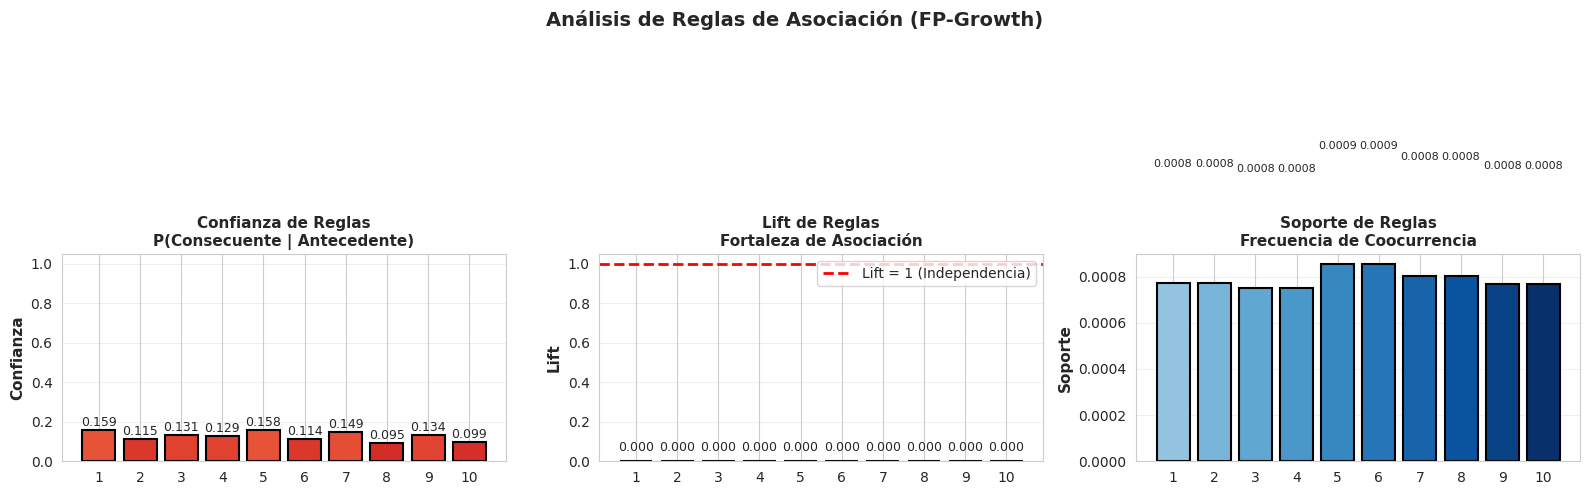

✓ Visualizaciones completadas


CONCLUSIONES Y ANÁLISIS

✓ REGLAS ENCONTRADAS:
  Se identificaron 115455 reglas de asociación significativas entre películas
  con calificaciones positivas (≥ 3.5/5)

✓ PATRONES DESTACADOS:
  • La regla más fuerte tiene Lift = 0.0002
    Antecedente: Harry Potter and the Half-Blood Prince (2009)
    Consecuente: Harry Potter and the Order of the Phoenix (2007)
    Confianza: 15.86% de usuarios que aman
    el antecedente también aman el consecuente.

  • 0 reglas con asociación fuerte (Lift > 1.2)
  • Confianza promedio: 6.87%
  • Lift promedio: 0.0000x

✓ APLICACIONES PRÁCTICAS:
  • Recomendación cruzada: Sugerir películas basadas en preferencias previas
  • Agrupación de catálogo: Organizar películas similares en la plataforma
  • Marketing: Campañas dirigidas a usuarios interesados en géneros relacionados
  • Análisis de comunidades: Identificar subgrupos de películas con fans comunes



In [27]:
import matplotlib.pyplot as plt
import numpy as np

if rules_sorted:
    # Preparar datos para visualización
    top_n = builtins.min(10, len(rules_sorted))
    rule_labels = [
        f"{rule['antecedent_titles'][0][:20]}\n→ {rule['consequent_titles'][0][:20]}"
        for rule in enriched_rules[:top_n]
    ]
    confidence_vals = [rule['confidence'] for rule in enriched_rules[:top_n]]
    lift_vals = [rule['lift'] for rule in enriched_rules[:top_n]]
    support_vals = [rule['support'] for rule in enriched_rules[:top_n]]
    
    # Crear figura con 3 subgráficos
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle('Análisis de Reglas de Asociación (FP-Growth)', fontsize=14, fontweight='bold')
    
    # 1. Gráfico de Confianza
    x_pos = np.arange(len(rule_labels))
    colors_conf = plt.cm.RdYlGn(np.array(confidence_vals))
    axes[0].bar(x_pos, confidence_vals, color=colors_conf, edgecolor='black', linewidth=1.5)
    axes[0].set_xticks(x_pos)
    axes[0].set_xticklabels(range(1, len(rule_labels) + 1))
    axes[0].set_ylabel('Confianza', fontsize=11, fontweight='bold')
    axes[0].set_title('Confianza de Reglas\nP(Consecuente | Antecedente)', fontsize=11, fontweight='bold')
    axes[0].set_ylim([0, 1.05])
    axes[0].grid(axis='y', alpha=0.3)
    for i, v in enumerate(confidence_vals):
        axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)
    
    # 2. Gráfico de Lift
    colors_lift = plt.cm.Spectral_r(np.linspace(0, 1, len(lift_vals)))
    axes[1].bar(x_pos, lift_vals, color=colors_lift, edgecolor='black', linewidth=1.5)
    axes[1].axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='Lift = 1 (Independencia)')
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels(range(1, len(rule_labels) + 1))
    axes[1].set_ylabel('Lift', fontsize=11, fontweight='bold')
    axes[1].set_title('Lift de Reglas\nFortaleza de Asociación', fontsize=11, fontweight='bold')
    axes[1].legend(loc='upper right')
    axes[1].grid(axis='y', alpha=0.3)
    for i, v in enumerate(lift_vals):
        axes[1].text(i, v + 0.05, f'{v:.3f}', ha='center', fontsize=9)
    
    # 3. Gráfico de Soporte
    colors_supp = plt.cm.Blues(np.linspace(0.4, 1, len(support_vals)))
    axes[2].bar(x_pos, support_vals, color=colors_supp, edgecolor='black', linewidth=1.5)
    axes[2].set_xticks(x_pos)
    axes[2].set_xticklabels(range(1, len(rule_labels) + 1))
    axes[2].set_ylabel('Soporte', fontsize=11, fontweight='bold')
    axes[2].set_title('Soporte de Reglas\nFrecuencia de Coocurrencia', fontsize=11, fontweight='bold')
    axes[2].grid(axis='y', alpha=0.3)
    for i, v in enumerate(support_vals):
        axes[2].text(i, v + 0.0005, f'{v:.4f}', ha='center', fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Visualizaciones completadas\n")

# Análisis y conclusiones
print("\n" + "="*70)
print("CONCLUSIONES Y ANÁLISIS")
print("="*70)

if rules_sorted:
    print("\n✓ REGLAS ENCONTRADAS:")
    print(f"  Se identificaron {len(rules_sorted)} reglas de asociación significativas entre películas")
    print(f"  con calificaciones positivas (≥ {RATING_THRESHOLD_ASSOC}/5)\n")
    
    print("✓ PATRONES DESTACADOS:")
    best_rule = enriched_rules[0]
    print(f"  • La regla más fuerte tiene Lift = {best_rule['lift']:.4f}")
    print(f"    Antecedente: {best_rule['antecedent_titles'][0]}")
    print(f"    Consecuente: {best_rule['consequent_titles'][0]}")
    print(f"    Confianza: {best_rule['confidence']*100:.2f}% de usuarios que aman")
    print(f"    el antecedente también aman el consecuente.\n")
    
    strong_rules = [r for r in enriched_rules if r['lift'] > 1.2]
    print(f"  • {len(strong_rules)} reglas con asociación fuerte (Lift > 1.2)")
    print(f"  • Confianza promedio: {builtins.sum([r['confidence'] for r in enriched_rules])/len(enriched_rules)*100:.2f}%")
    print(f"  • Lift promedio: {builtins.sum([r['lift'] for r in enriched_rules])/len(enriched_rules):.4f}x\n")
    
    print("✓ APLICACIONES PRÁCTICAS:")
    print("  • Recomendación cruzada: Sugerir películas basadas en preferencias previas")
    print("  • Agrupación de catálogo: Organizar películas similares en la plataforma")
    print("  • Marketing: Campañas dirigidas a usuarios interesados en géneros relacionados")
    print("  • Análisis de comunidades: Identificar subgrupos de películas con fans comunes\n")
else:
    print("⚠ No se encontraron suficientes reglas con los parámetros especificados")
    print(f"  Considera reducir el soporte mínimo ({MIN_SUPPORT}) o confianza mínima ({MIN_CONFIDENCE})\n")

print("="*70)
